In [1]:
"""
Single-row getter controlled by `mode`.

Modes (ONLY these):
  - "smi"      -> pooled MolFormer (SMILES) embedding from candidate CIDs (FAST)
  - "text"     -> pooled BioLinkBERT embedding from candidate CIDs (FAST)
  - "msi_chan" -> MSI channel embedding from embeddings_all.npy (FAST; tile+chan lookup; gated by ch_df valid channels)
  - "msi_cls"  -> MSI CLS embedding from cls_embeddings.npy (FAST; tile lookup)
  - "mz"       -> m/z scalar (FAST; uses chan_row["mz"] if present, else NPZ fallback)
  - "img"      -> MSI channel image (SLOW; loads NPZ patch)

Key point: mode controls what is computed.
- mode="smi"/"text" does NOT touch MSI meta/embeddings/NPZ.
- mode="msi_chan"/"msi_cls" does NOT touch NPZ (fast; uses saved embeddings + meta join).
- mode="img" will load the NPZ (slow).

IMPORTANT for msi_chan:
- embeddings_all.npy contains 32 embeddings per tile, including "blank" channels whose IMAGE was all-zeros.
- ch_df contains ONLY real/nonzero channels.
- We therefore GATE msi_chan by a valid-channel mask built from ch_df:
    if channel not present in ch_df for that tile -> return None

Also: your embeddings_all meta uses split, but ch_df doesn't.
We auto-resolve split by checking which (ds,tr,tc,split) exists in the embeddings_all index.
"""

from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd

# -------------------------
# CONFIG
# -------------------------
BASE = Path("metaspace_images_dump")

CHAN_PQ = BASE / "channels_with_candidates.parquet"
PQ      = BASE / "molformer_pubchem_index_enriched_semantic.parquet"
SMI_NPY = BASE / "molformer_pubchem_embeddings.npy"
TXT_NPY = BASE / "cand_molecule_biolinkbert_embeddings.npy"

# MSI CLS (tile-level)
MSI_EMB_DIR   = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV  = MSI_EMB_DIR / "meta.csv"
MSI_CLS_NPY   = MSI_EMB_DIR / "cls_embeddings.npy"  # (Ntiles, D_cls)

# MSI per-channel embeddings (N,C,D) + matching meta
MSI_CHAN_DIR       = Path("msi-vitmae_REBUILT2_2/embeddings_single_channel").resolve()
MSI_CHAN_NPY       = MSI_CHAN_DIR / "embeddings_all.npy"   # (N_total, C=32, D)
MSI_CHAN_META_CSV  = MSI_CHAN_DIR / "meta__all.csv"        # (N_total rows), includes split

# If meta.csv sample_path is relative, set NPZ_ROOT
NPZ_ROOT = None  # e.g. Path(r"Y:\coskun-lab\Efe\MSI Foundation Model")

CAND_CIDS_COL = "cand_pubchem_cids"
C_TARGET = 32  # padded channel count

# When split is needed but chan_row lacks it, we try in this order first:
SPLIT_PREFER_ORDER = ("train", "val", "test")


# -------------------------
# Helpers (CIDs)
# -------------------------
_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)

def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None

def parse_cids_field(cand_pubchem_cids) -> list[str]:
    if cand_pubchem_cids is None:
        return []
    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        toks = re.split(r"[;,|]\s*|\s+\|\s+|\s*;\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    # preserve order, drop dups
    seen = set()
    uniq = []
    for cid in out:
        if cid not in seen:
            uniq.append(cid)
            seen.add(cid)
    return uniq

def build_cid_to_index_map(pq_df: pd.DataFrame, cid_col: str = "cid") -> dict[str, int]:
    if cid_col not in pq_df.columns:
        raise KeyError(f"PQ missing {cid_col!r}. Columns: {list(pq_df.columns)}")
    cid_series = pq_df[cid_col].astype(str).map(normalize_cid)
    cid_to_idx = {}
    for i, cid in enumerate(cid_series.values):
        if cid and cid not in cid_to_idx:
            cid_to_idx[cid] = i
    return cid_to_idx

def gather_candidate_indices_for_channel_row(
    chan_row: pd.Series,
    cid_to_idx: dict[str, int],
    cand_cids_col: str = CAND_CIDS_COL,
) -> tuple[list[str], np.ndarray]:
    cids = parse_cids_field(chan_row.get(cand_cids_col))
    idxs = []
    cids_found = []
    for cid in cids:
        j = cid_to_idx.get(cid)
        if j is None:
            continue
        idxs.append(j)
        cids_found.append(cid)
    return cids_found, np.asarray(idxs, dtype=np.int64)


# -------------------------
# Helpers (math)
# -------------------------
def l2(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    n = float(np.linalg.norm(x) + eps)
    return x / n

def mean_pool(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X)
    if X.size == 0:
        raise ValueError("Cannot mean-pool an empty array.")
    return X.mean(axis=0)


# -------------------------
# Helpers (MSI lookup)
# -------------------------
def _resolve_npz_path(sample_path: str | Path) -> Path:
    p = Path(str(sample_path))
    if p.is_absolute():
        return p
    if NPZ_ROOT is not None:
        return Path(NPZ_ROOT) / p
    return p

def infer_chan_index(chan_row: pd.Series) -> int:
    # Prefer explicit column
    if "channel_idx" in chan_row.index:
        v = chan_row.get("channel_idx")
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            return int(v)

    for col in ["chan", "channel", "channel_i", "ch", "c"]:
        if col in chan_row.index:
            v = chan_row.get(col)
            if v is None or (isinstance(v, float) and np.isnan(v)):
                continue
            return int(v)

    raise KeyError(
        "Could not find channel index column in channel row "
        "(expected 'channel_idx' or one of chan/channel/channel_i/ch/c)."
    )

def read_msi_image_and_mz_from_npz(npz_path: Path, chan_idx: int) -> tuple[np.ndarray, float | None]:
    if not npz_path.exists():
        raise FileNotFoundError(f"NPZ not found: {npz_path}")

    with np.load(npz_path, allow_pickle=False) as z:
        if "patch" not in z:
            raise KeyError(f"NPZ missing key 'patch': {npz_path} keys={list(z.keys())}")
        patch = z["patch"]
        mz = z["mz"] if "mz" in z else None

    if patch.ndim != 3:
        raise ValueError(f"Expected patch.ndim==3, got shape={patch.shape}")

    if mz is not None and np.asarray(mz).ndim == 1 and patch.shape[-1] == np.asarray(mz).shape[0]:
        # (H,W,C)
        if not (0 <= chan_idx < patch.shape[-1]):
            raise IndexError(f"chan_idx={chan_idx} out of bounds for patch shape {patch.shape}")
        img = patch[..., chan_idx]
    else:
        # assume (C,H,W)
        if not (0 <= chan_idx < patch.shape[0]):
            raise IndexError(f"chan_idx={chan_idx} out of bounds for patch shape {patch.shape}")
        img = patch[chan_idx, ...]

    mz_val = None
    if mz is not None:
        mz = np.asarray(mz).reshape(-1)
        if 0 <= chan_idx < mz.shape[0]:
            mz_val = float(mz[chan_idx])

    return np.asarray(img), mz_val


# -------------------------
# Valid-channel gating map from ch_df
# -------------------------
def build_valid_chan_map_from_chdf(ch_df: pd.DataFrame, C: int = 32) -> dict[tuple, np.ndarray]:
    """
    Returns:
      valid[(dataset_id, tile_r, tile_c)] = boolean mask length C
    True indicates that channel exists as a REAL/nonzero channel in ch_df.
    """
    need = {"dataset_id", "tile_r", "tile_c", "channel_idx"}
    miss = need - set(ch_df.columns)
    if miss:
        raise KeyError(f"ch_df missing columns: {sorted(miss)}")

    valid: dict[tuple, np.ndarray] = {}
    for (ds, tr, tc), g in ch_df.groupby(["dataset_id", "tile_r", "tile_c"], sort=False):
        mask = np.zeros(C, dtype=bool)
        idxs = g["channel_idx"].astype(int).values
        idxs = idxs[(0 <= idxs) & (idxs < C)]
        mask[idxs] = True
        valid[(str(ds), int(tr), int(tc))] = mask
    return valid


# -------------------------
# Build tile index for CLS meta (no split)
# -------------------------
def build_msi_tile_index(meta_df: pd.DataFrame) -> dict[tuple, int]:
    """
    For MSI_META_CSV: (dataset_id, tile_r, tile_c) -> row index
    """
    needed = {"dataset_id", "tile_r", "tile_c"}
    miss = needed - set(meta_df.columns)
    if miss:
        raise KeyError(f"MSI meta.csv missing columns: {sorted(miss)}")

    key_to_i = {}
    for i, r in meta_df.reset_index(drop=True).iterrows():
        key = (str(r["dataset_id"]), int(r["tile_r"]), int(r["tile_c"]))
        if key not in key_to_i:
            key_to_i[key] = i
    return key_to_i


# -------------------------
# Build tile index for channel embeddings meta (has split)
# -------------------------
def build_chan_tile_index(meta_df: pd.DataFrame) -> dict[tuple, int]:
    """
    For MSI_CHAN_META_CSV:
      if has split -> (dataset_id, tile_r, tile_c, split) -> row index
      else         -> (dataset_id, tile_r, tile_c)        -> row index
    """
    need = {"dataset_id", "tile_r", "tile_c"}
    miss = need - set(meta_df.columns)
    if miss:
        raise KeyError(f"Channel meta missing columns: {sorted(miss)}")

    use_split = "split" in meta_df.columns
    key_to_i = {}

    for i, r in meta_df.reset_index(drop=True).iterrows():
        ds = str(r["dataset_id"])
        tr = int(r["tile_r"])
        tc = int(r["tile_c"])
        if use_split:
            sp = str(r["split"])
            key = (ds, tr, tc, sp)
        else:
            key = (ds, tr, tc)
        if key not in key_to_i:
            key_to_i[key] = i

    return key_to_i


def infer_tile_key_for_chan_embeddings(
    chan_row: pd.Series,
    *,
    chan_meta_has_split: bool,
    chan_tile_to_i: dict[tuple, int] | None = None,
    prefer_order: tuple[str, ...] = SPLIT_PREFER_ORDER,
) -> tuple:
    """
    Returns correct key to index embeddings_all.

    If channel-meta has split:
      - If chan_row has split: use it
      - Else: auto-resolve by testing (ds,tr,tc,split) in prefer_order and then any match.

    Requires chan_tile_to_i when chan_meta_has_split=True and chan_row has no split.
    """
    ds = str(chan_row.get("dataset_id"))
    tr = int(chan_row.get("tile_r"))
    tc = int(chan_row.get("tile_c"))

    if not chan_meta_has_split:
        return (ds, tr, tc)

    if "split" in chan_row.index:
        return (ds, tr, tc, str(chan_row.get("split")))

    if chan_tile_to_i is None:
        raise ValueError("Need chan_tile_to_i to auto-resolve split for channel embeddings.")

    # Prefer train -> val -> test
    for sp in prefer_order:
        key = (ds, tr, tc, sp)
        if key in chan_tile_to_i:
            return key

    # Fallback: any match with that tile
    prefix = (ds, tr, tc)
    for key in chan_tile_to_i.keys():
        if isinstance(key, tuple) and len(key) == 4 and key[:3] == prefix:
            return key

    # Nothing found
    return (ds, tr, tc, prefer_order[0])


# -------------------------
# Core: single-row getter by mode
# -------------------------
def get_row_outputs(
    chan_row: pd.Series,
    *,
    mode: str,
    # molecule
    cid_to_idx: dict[str, int] | None = None,
    Zs_all: np.ndarray | None = None,
    Zt_all: np.ndarray | None = None,
    cand_cids_col: str = CAND_CIDS_COL,
    # MSI CLS
    msi_meta_df: pd.DataFrame | None = None,
    msi_tile_to_i: dict[tuple, int] | None = None,
    Z_msi_cls_all: np.ndarray | None = None,
    # MSI channel embeddings
    Z_msi_chan_all: np.ndarray | None = None,     # (N,C,D)
    chan_meta_has_split: bool | None = None,
    chan_tile_to_i: dict[tuple, int] | None = None,
    valid_chan_map: dict[tuple, np.ndarray] | None = None,
    debug: bool = False,
):
    """
    Returns ONE value depending on `mode`:

      mode="smi"      -> np.ndarray (Ds,) or None
      mode="text"     -> np.ndarray (Dt,) or None
      mode="msi_cls"  -> np.ndarray (Dcls,) or None
      mode="msi_chan" -> np.ndarray (Dchan,) or None
      mode="mz"       -> float or None
      mode="img"      -> np.ndarray (H,W) or None
    """
    mode = mode.lower().strip()
    if mode not in {"smi", "text", "msi_chan", "msi_cls", "mz", "img"}:
        raise ValueError('mode must be one of: "smi", "text", "msi_chan", "msi_cls", "mz", "img"')

    # ---------- mz ----------
    if mode == "mz":
        v = chan_row.get("mz", None)
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            return float(v)

        # fallback via NPZ
        if msi_meta_df is None or msi_tile_to_i is None:
            return None
        chan_idx = infer_chan_index(chan_row)
        key = (str(chan_row.get("dataset_id")), int(chan_row.get("tile_r")), int(chan_row.get("tile_c")))
        i_tile = msi_tile_to_i.get(key)
        if i_tile is None or "sample_path" not in msi_meta_df.columns:
            return None
        npz_path = _resolve_npz_path(msi_meta_df.loc[i_tile, "sample_path"])
        _, mz_val = read_msi_image_and_mz_from_npz(npz_path, chan_idx)
        return mz_val

    # ---------- molecule embeddings ----------
    if mode in {"smi", "text"}:
        if cid_to_idx is None:
            raise ValueError("cid_to_idx required for mode='smi'/'text'")
        if mode == "smi" and Zs_all is None:
            raise ValueError("Zs_all required for mode='smi'")
        if mode == "text" and Zt_all is None:
            raise ValueError("Zt_all required for mode='text'")

        _, idx = gather_candidate_indices_for_channel_row(
            chan_row=chan_row,
            cid_to_idx=cid_to_idx,
            cand_cids_col=cand_cids_col,
        )
        if idx.size == 0:
            return None

        if mode == "smi":
            return l2(mean_pool(np.asarray(Zs_all[idx])))
        else:
            return l2(mean_pool(np.asarray(Zt_all[idx])))

    # ---------- MSI CLS ----------
    if mode == "msi_cls":
        if msi_tile_to_i is None or Z_msi_cls_all is None:
            raise ValueError("msi_tile_to_i and Z_msi_cls_all required for mode='msi_cls'")
        key = (str(chan_row.get("dataset_id")), int(chan_row.get("tile_r")), int(chan_row.get("tile_c")))
        i_tile = msi_tile_to_i.get(key)
        if i_tile is None:
            return None
        return l2(np.asarray(Z_msi_cls_all[i_tile], dtype=np.float32))

    # ---------- MSI channel embedding (gated) ----------
    if mode == "msi_chan":
        if Z_msi_chan_all is None or chan_tile_to_i is None or chan_meta_has_split is None:
            raise ValueError("Z_msi_chan_all, chan_tile_to_i, chan_meta_has_split required for mode='msi_chan'")

        ds = str(chan_row.get("dataset_id"))
        tr = int(chan_row.get("tile_r"))
        tc = int(chan_row.get("tile_c"))
        k  = infer_chan_index(chan_row)

        # gate: ensure this channel is a "real" channel per ch_df
        if valid_chan_map is not None:
            mask = valid_chan_map.get((ds, tr, tc))
            if mask is not None:
                if not (0 <= k < len(mask)) or (not mask[k]):
                    if debug:
                        print(f"[msi_chan] gated OUT (not in ch_df) tile={(ds,tr,tc)} k={k}")
                    return None

        key_tile = infer_tile_key_for_chan_embeddings(
            chan_row,
            chan_meta_has_split=chan_meta_has_split,
            chan_tile_to_i=chan_tile_to_i,
            prefer_order=SPLIT_PREFER_ORDER,
        )
        i = chan_tile_to_i.get(key_tile)
        if i is None:
            if debug:
                print(f"[msi_chan] tile not found in chan meta: key={key_tile}")
            return None

        if Z_msi_chan_all.ndim != 3:
            raise ValueError(f"Expected Z_msi_chan_all to be 3D (N,C,D), got shape={Z_msi_chan_all.shape}")
        if not (0 <= k < Z_msi_chan_all.shape[1]):
            if debug:
                print(f"[msi_chan] channel idx out of bounds: k={k}, C={Z_msi_chan_all.shape[1]}")
            return None

        return l2(np.asarray(Z_msi_chan_all[i, k, :], dtype=np.float32))

    # ---------- MSI image (SLOW) ----------
    # mode == "img"
    if msi_meta_df is None or msi_tile_to_i is None:
        raise ValueError("msi_meta_df and msi_tile_to_i required for mode='img'")

    chan_idx = infer_chan_index(chan_row)
    key = (str(chan_row.get("dataset_id")), int(chan_row.get("tile_r")), int(chan_row.get("tile_c")))
    i_tile = msi_tile_to_i.get(key)
    if i_tile is None:
        return None
    if "sample_path" not in msi_meta_df.columns:
        return None

    npz_path = _resolve_npz_path(msi_meta_df.loc[i_tile, "sample_path"])
    img, _ = read_msi_image_and_mz_from_npz(npz_path, chan_idx)
    return img


# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    # Load channel rows
    ch_df = pd.read_parquet(CHAN_PQ)

    # Build CID->index map
    pq_df = pd.read_parquet(PQ, columns=["cid"])
    cid_to_idx = build_cid_to_index_map(pq_df, cid_col="cid")

    # Memmap molecule embeddings
    ZS_ALL = np.load(SMI_NPY, mmap_mode="r")  # (Nmol, Ds)
    ZT_ALL = np.load(TXT_NPY, mmap_mode="r")  # (Nmol, Dt)

    # MSI tile meta + tile index (for CLS and NPZ paths)
    msi_meta = pd.read_csv(MSI_META_CSV)
    msi_tile_to_i = build_msi_tile_index(msi_meta)

    # MSI CLS
    Z_MSI_CLS = np.load(MSI_CLS_NPY, mmap_mode="r")

    # Valid-channel gating map from ch_df
    valid_chan_map = build_valid_chan_map_from_chdf(ch_df, C=C_TARGET)

    # Load channel embeddings + its OWN meta
    if not MSI_CHAN_NPY.exists():
        raise FileNotFoundError(f"Missing channel embeddings: {MSI_CHAN_NPY}")
    if not MSI_CHAN_META_CSV.exists():
        raise FileNotFoundError(f"Missing channel embeddings meta: {MSI_CHAN_META_CSV}")

    Z_CHAN = np.load(MSI_CHAN_NPY, mmap_mode="r")  # (N,C,D)
    chan_meta = pd.read_csv(MSI_CHAN_META_CSV)
    chan_meta_has_split = "split" in chan_meta.columns
    chan_tile_to_i = build_chan_tile_index(chan_meta)

    # Grab one row
    row = ch_df.iloc[0]

    z_smi = get_row_outputs(row, mode="smi", cid_to_idx=cid_to_idx, Zs_all=ZS_ALL)
    z_txt = get_row_outputs(row, mode="text", cid_to_idx=cid_to_idx, Zt_all=ZT_ALL)
    z_cls = get_row_outputs(
        row, mode="msi_cls",
        msi_meta_df=msi_meta, msi_tile_to_i=msi_tile_to_i,
        Z_msi_cls_all=Z_MSI_CLS,
    )
    z_ch  = get_row_outputs(
        row, mode="msi_chan",
        Z_msi_chan_all=Z_CHAN,
        chan_meta_has_split=chan_meta_has_split,
        chan_tile_to_i=chan_tile_to_i,
        valid_chan_map=valid_chan_map,
        debug=True,
    )
    mz    = get_row_outputs(row, mode="mz", msi_meta_df=msi_meta, msi_tile_to_i=msi_tile_to_i)
    img   = get_row_outputs(row, mode="img", msi_meta_df=msi_meta, msi_tile_to_i=msi_tile_to_i)

    print("smi:", None if z_smi is None else z_smi.shape)
    print("txt:", None if z_txt is None else z_txt.shape)
    print("cls:", None if z_cls is None else z_cls.shape)
    print("chan:", None if z_ch is None else z_ch.shape)
    print("mz:", mz)
    print("img:", None if img is None else img.shape, img.dtype if img is not None else "")

smi: (768,)
txt: (768,)
cls: (768,)
chan: (768,)
mz: 283.26422119140625
img: (189, 268) uint16


In [2]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import umap
from pathlib import Path

# =============================================================================
# UMAP FUSION (3 variants)
#   (A) tile-level fusion:    SMILES + MSI_CLS              -> smi_msi_embeddings.npy  (KEEP)
#   (B) channel-level fusion: SMILES + MSI_CHAN             -> smi_msi_chan_embeddings.npy
#   (C) combined fusion:      SMILES + MSI_CLS + MSI_CHAN   -> smi_msi_cls_chan_embeddings.npy
#
# All use the SAME sampled rows (row_ids) for fair comparison.
#
# Assumes these exist in scope (from your full getter script):
#   - CHAN_PQ, PQ, SMI_NPY, MSI_META_CSV, MSI_CLS_NPY, MSI_CHAN_NPY, MSI_CHAN_META_CSV
#   - build_cid_to_index_map(), build_msi_tile_index(), build_chan_tile_index(),
#     build_valid_chan_map_from_chdf(), get_row_outputs()
# =============================================================================

# -------------------------
# CONFIG
# -------------------------
MAX_ROWS = 50000
SEED = 6740

UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.05
UMAP_METRIC = "euclidean"

EPS = 1e-6

# Weights are applied AFTER z-score normalization.
# Make these sum to 1.0 for interpretability (not required).
W_SMI  = 1/3
W_CLS  = 1/3   # MSI tile CLS
W_CHAN = 1/3   # MSI channel embedding

# For the 2-way fusions, we reuse these:
W_TILE_SMI = 0.5
W_TILE_CLS = 0.5

W_CHF_SMI  = 0.5
W_CHF_CHAN = 0.5

# outputs
OUT_DIR = Path(r"Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_TILE_FUSED = OUT_DIR / "smi_msi_embeddings.npy"                 # (N,D)  SMILES + MSI_CLS (KEEP)
OUT_CHAN_FUSED = OUT_DIR / "smi_msi_chan_embeddings.npy"            # (N,D)  SMILES + MSI_CHAN
OUT_ALL_FUSED  = OUT_DIR / "smi_msi_cls_chan_embeddings.npy"        # (N,D)  SMILES + CLS + CHAN  (NEW)

OUT_ROW_IDS    = OUT_DIR / "umap_row_ids.npy"                       # same row_ids for all
OUT_XY_TILE    = OUT_DIR / "umap_XY.npy"                            # tile-fused
OUT_XY_CHAN    = OUT_DIR / "umap_XY_chan.npy"                       # channel-fused
OUT_XY_ALL     = OUT_DIR / "umap_XY_cls_chan.npy"                   # combined-fused (NEW)

# -------------------------
# utils
# -------------------------
def zscore_cols(X, eps=1e-6):
    X = np.asarray(X, dtype=np.float32)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True) + eps
    return (X - mu) / sd

def l2_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float32)
    n = np.linalg.norm(X, axis=1, keepdims=True) + eps
    return X / n

def fit_umap(X, seed=6740):
    um = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        n_components=2,
        metric=UMAP_METRIC,
        random_state=seed,
    )
    return um.fit_transform(X)

# =============================================================================
# Load channels + subsample
# =============================================================================
ch_df = pd.read_parquet(CHAN_PQ)

rng = np.random.default_rng(SEED)
idx_all = np.arange(len(ch_df), dtype=np.int64)
if MAX_ROWS is not None and int(MAX_ROWS) < len(idx_all):
    idx_pick = rng.choice(idx_all, size=int(MAX_ROWS), replace=False)
else:
    idx_pick = idx_all

# =============================================================================
# Load what we need for SMILES
# =============================================================================
pq_df = pd.read_parquet(PQ, columns=["cid"])
cid_to_idx = build_cid_to_index_map(pq_df, cid_col="cid")
ZS_ALL = np.load(SMI_NPY, mmap_mode="r")  # (Nmol, Ds)

# =============================================================================
# Load what we need for MSI_CLS (tile)
# =============================================================================
msi_meta = pd.read_csv(MSI_META_CSV)
msi_tile_to_i = build_msi_tile_index(msi_meta)   # (dataset_id,tile_r,tile_c)->i
Z_MSI_CLS = np.load(MSI_CLS_NPY, mmap_mode="r")  # (Ntiles, D)

# =============================================================================
# Load what we need for MSI_CHAN (channel embeddings_all)
# =============================================================================
Z_CHAN = np.load(MSI_CHAN_NPY, mmap_mode="r")            # (N, C, D)
chan_meta = pd.read_csv(MSI_CHAN_META_CSV)               # (N rows; maybe includes split)
chan_meta_has_split = "split" in chan_meta.columns
chan_tile_to_i = build_chan_tile_index(chan_meta)        # (ds,tr,tc,split?)->i

# gating: only "real channels" in ch_df
valid_chan_map = build_valid_chan_map_from_chdf(ch_df, C=Z_CHAN.shape[1])

# =============================================================================
# Collect blocks (same rows for all fusions)
# =============================================================================
row_ids = []
Z_smi_list  = []
Z_cls_list  = []
Z_chan_list = []

for rid in tqdm(idx_pick, desc="Collect smi + msi_cls + msi_chan"):
    r = ch_df.iloc[int(rid)]

    z_smi = get_row_outputs(r, mode="smi", cid_to_idx=cid_to_idx, Zs_all=ZS_ALL)
    if z_smi is None:
        continue

    z_cls = get_row_outputs(
        r,
        mode="msi_cls",
        msi_meta_df=msi_meta,
        msi_tile_to_i=msi_tile_to_i,
        Z_msi_cls_all=Z_MSI_CLS,
    )
    if z_cls is None:
        continue

    z_ch = get_row_outputs(
        r,
        mode="msi_chan",
        Z_msi_chan_all=Z_CHAN,
        chan_meta_has_split=chan_meta_has_split,
        chan_tile_to_i=chan_tile_to_i,
        valid_chan_map=valid_chan_map,
        debug=False,
    )
    if z_ch is None:
        continue

    row_ids.append(int(rid))
    Z_smi_list.append(np.asarray(z_smi, dtype=np.float32))
    Z_cls_list.append(np.asarray(z_cls, dtype=np.float32))
    Z_chan_list.append(np.asarray(z_ch, dtype=np.float32))

row_ids = np.asarray(row_ids, dtype=np.int64)
Z_smi  = np.stack(Z_smi_list, axis=0)    # (N,D)
Z_cls  = np.stack(Z_cls_list, axis=0)    # (N,D)
Z_chan = np.stack(Z_chan_list, axis=0)   # (N,D)

print("Rows:", len(row_ids))
print("Z_smi :", Z_smi.shape)
print("Z_cls :", Z_cls.shape)
print("Z_chan:", Z_chan.shape)

# =============================================================================
# Normalize blocks across rows (z-score columns)
# =============================================================================
Z_smi_n  = zscore_cols(Z_smi, eps=EPS)
Z_cls_n  = zscore_cols(Z_cls, eps=EPS)
Z_chan_n = zscore_cols(Z_chan, eps=EPS)

# =============================================================================
# (A) Tile fusion: SMILES + CLS  (KEEP old output filename)
# =============================================================================
Z_fused_tile = (W_TILE_SMI * Z_smi_n) + (W_TILE_CLS * Z_cls_n)
Z_fused_tile = l2_rows(Z_fused_tile)

# =============================================================================
# (B) Channel fusion: SMILES + CHAN
# =============================================================================
Z_fused_chan = (W_CHF_SMI * Z_smi_n) + (W_CHF_CHAN * Z_chan_n)
Z_fused_chan = l2_rows(Z_fused_chan)

# =============================================================================
# (C) Combined fusion: SMILES + CLS + CHAN   (weighted sum)
# =============================================================================
# Note: weights apply after z-score so they’re comparable in scale.
Z_fused_all = (W_SMI * Z_smi_n) + (W_CLS * Z_cls_n) + (W_CHAN * Z_chan_n)
Z_fused_all = l2_rows(Z_fused_all)

# =============================================================================
# UMAPs (separate)
# =============================================================================
XY_tile = fit_umap(Z_fused_tile, seed=SEED)
print("UMAP tile XY:", XY_tile.shape)

XY_chan = fit_umap(Z_fused_chan, seed=SEED)
print("UMAP chan XY:", XY_chan.shape)

XY_all = fit_umap(Z_fused_all, seed=SEED)
print("UMAP all  XY:", XY_all.shape)

# =============================================================================
# Save
# =============================================================================
np.save(OUT_TILE_FUSED, Z_fused_tile)   # KEEP old filename
np.save(OUT_CHAN_FUSED, Z_fused_chan)
np.save(OUT_ALL_FUSED,  Z_fused_all)

np.save(OUT_ROW_IDS, row_ids)           # same row_ids for all

np.save(OUT_XY_TILE, XY_tile)           # KEEP old filename
np.save(OUT_XY_CHAN, XY_chan)
np.save(OUT_XY_ALL,  XY_all)

print("[OK] Saved:")
print(" -", OUT_TILE_FUSED)
print(" -", OUT_CHAN_FUSED)
print(" -", OUT_ALL_FUSED)
print(" -", OUT_ROW_IDS)
print(" -", OUT_XY_TILE)
print(" -", OUT_XY_CHAN)
print(" -", OUT_XY_ALL)

Collect smi + msi_cls + msi_chan: 100%|██████████| 50000/50000 [04:35<00:00, 181.77it/s] 


Rows: 48021
Z_smi : (48021, 768)
Z_cls : (48021, 768)
Z_chan: (48021, 768)


c:\Users\eozturk7\AppData\Local\anaconda3\envs\python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP tile XY: (48021, 2)


c:\Users\eozturk7\AppData\Local\anaconda3\envs\python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP chan XY: (48021, 2)


c:\Users\eozturk7\AppData\Local\anaconda3\envs\python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP all  XY: (48021, 2)
[OK] Saved:
 - Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\smi_msi_embeddings.npy
 - Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\smi_msi_chan_embeddings.npy
 - Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\smi_msi_cls_chan_embeddings.npy
 - Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\umap_row_ids.npy
 - Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\umap_XY.npy
 - Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\umap_XY_chan.npy
 - Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\umap_XY_cls_chan.npy


### Interactive atlas

In [1]:
from __future__ import annotations

import json
import re
import urllib.request
import urllib.error


OLLAMA_URL = "http://localhost:11434/api/chat"
MODEL = "qwen2.5:7b-instruct"
TIMEOUT_SEC = 60

ALLOWED_KEYS = {
    "polarity",
    "organism",
    "Organism_Part",
    "Condition",
    "analyzerType",
    "ionisationSource",
    "hmdb_kingdom",
    "hmdb_super_class",
    "hmdb_class",
    "hmdb_sub_class",
    "hmdb_direct_parent",
    "mz_min",
    "mz_max",
    "n_cand_min",
    "n_cand_max",
    "n_cand_eq",
}

HMDB_KEYS = {
    "hmdb_kingdom",
    "hmdb_super_class",
    "hmdb_class",
    "hmdb_sub_class",
    "hmdb_direct_parent",
}

DEFAULT_HMDB_KEY = "hmdb_class"


# -----------------------------
# Canonical vocab (minimal)
# -----------------------------
ORGANISM_CANON = {
    "mouse": "Mus musculus",
    "mice": "Mus musculus",
    "mus musculus": "Mus musculus",
    "human": "Homo sapiens",
    "homo sapiens": "Homo sapiens",
}

# Only these are allowed to survive as "organism" unless you add more
ALLOWED_ORGANISMS = {
    "Mus musculus",
    "Homo sapiens",
    "Rattus norvegicus",
    "Danio rerio (zebrafish)",
    "Mixed",
    "human,pig",   # you want to allow this literal multi-organism token
}

ORGANISM_PART_CANON = {
    "brain": "Brain",
    "cerebellum": "Cerebellum",
    "liver": "Liver",
    "kidney": "Kidney",
    "kideny": "Kideny",
    "heart": "Heart",
    "lung": "Lung",
    "colon": "Colon",
    "dorsal root ganglion": "Dorsal root ganglion",
    "crc tumor": "CRC Tumor",
}

CONDITION_CANON = {
    "high fat diet": "High Fat Diet",
    "hypoxia": "Hypoxia",
    "healthy": "Healthy",
    "stroke": "Stroke",
    "wildtipe": "Wildtipe",
    "wildtype": "Wildtype",
    "wild type": "Wild type",
    "wild-type": "wild-type",
}

KNOWN_HMDB_SUPER_CLASSES = {
    "benzenoids",
    "lipids_and_lipid-like_molecules",
    "organic_acids_and_derivatives",
    "organic_oxygen_compounds",
    "organic_nitrogen_compounds",
    "organoheterocyclic_compounds",
    "phenylpropanoids_and_polyketides",
}

KNOWN_HMDB_KINGDOMS = {
    "organic_compounds",
    "inorganic_compounds",
}

JUNK_TOKENS = {
    "samples", "sample",
    "dataset", "data",
    "inorganic", "organic",
    "organic_compounds", "inorganic_compounds",
    "benzenoids",
}

KNOWN_ANALYZERS = {
    "orbitrap",
    "q-tof", "qtof", "tof",
    "ft-icr", "fticr", "ftms",
    "timstof",
    "timstof flex",
    "timstof maldi",
    "exploris 240",
    "exploris 480",
    "exploris",
}

KNOWN_ION_SOURCES = {
    "maldi", "mald",
    "desi",
    "ap-maldi",
    "ap-smaldi",
    "ir-maldesi",
    "sims", "sims (bi3+)",
    "deffi",
    "prototype",
    "ld-reims",
}

HMDB_TERM_CANON = {
    "fatty acyls": "fatty_acyls",
    "fatty_acyls": "fatty_acyls",
    "organic compounds": "organic_compounds",
    "inorganic compounds": "inorganic_compounds",
    "organic_compounds": "organic_compounds",
    "inorganic_compounds": "inorganic_compounds",
    "lipids and lipid-like molecules": "lipids_and_lipid-like_molecules",
    "benzenoids": "benzenoids",
    # common plural fixes
    "flavonoid": "flavonoids",
    "flavonoids": "flavonoids",
}


def _coerce_number(x):
    try:
        return float(x)
    except Exception:
        return None


def _canon_spaces(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())


def _canon_keylike_token(s: str) -> str:
    t = _canon_spaces(s).lower()
    t = t.replace("(s)", "s")
    t = re.sub(r"[\"'`]", "", t)
    t = re.sub(r"[^a-z0-9 _\-+()]", "", t).strip()
    t = t.replace(" ", "_")
    t = re.sub(r"_+", "_", t)
    return t


def _canon_hmdb_term(term: str) -> str:
    raw = _canon_spaces(term).lower()
    raw = raw.replace("(s)", "s")
    raw = re.sub(r"[\"'`]", "", raw).strip()

    if raw in HMDB_TERM_CANON:
        return HMDB_TERM_CANON[raw]

    t = _canon_keylike_token(raw)
    if t.endswith("lipid"):
        t = t + "s"
    return t


def _extract_json_from_text(s: str) -> dict:
    s = (s or "").strip()
    if not s:
        return {}
    try:
        x = json.loads(s)
        return x if isinstance(x, dict) else {}
    except Exception:
        pass
    m = re.search(r"\{.*\}", s, flags=re.DOTALL)
    if m:
        try:
            x = json.loads(m.group(0))
            return x if isinstance(x, dict) else {}
        except Exception:
            return {}
    return {}


def _user_requested_polarity(original_query: str) -> str | None:
    q = (original_query or "").lower()
    if re.search(r"\bnegative\s+mode\b|\bnegative\s+polarity\b|\bneg\b", q):
        return "negative"
    if re.search(r"\bpositive\s+mode\b|\bpositive\s+polarity\b|\bpos\b", q):
        return "positive"
    m = re.search(r"\b(positive|negative)\b", q)
    if m:
        return m.group(1)
    return None


# -----------------------------
# Candidate extraction helpers
# -----------------------------
_CAND_MIN_PATTERNS = [
    re.compile(r"\bmore\s+than\s+(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\b>\s*(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\bat\s+least\s+(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\b(\d+(?:\.\d+)?)\s*(?:\+|plus)\s+(?:candidates?|cand|cands?)\b", re.I),
]

_CAND_MAX_PATTERNS = [
    re.compile(r"\bless\s+than\s+(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\b<\s*(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\bat\s+most\s+(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\bno\s+more\s+than\s+(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\b<=\s*(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
]

_CAND_EQ_PATTERNS = [
    re.compile(r"\bexactly\s+(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\bequal\s+to\s+(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
    re.compile(r"\b=\s*(\d+(?:\.\d+)?)\s+(?:candidates?|cand|cands?)\b", re.I),
]


def _extract_n_cand_eq_from_query(q: str) -> float | None:
    s = (q or "").strip()
    for pat in _CAND_EQ_PATTERNS:
        m = pat.search(s)
        if m:
            v = _coerce_number(m.group(1))
            if v is not None:
                return float(v)
    return None


def _extract_n_cand_min_from_query(q: str) -> float | None:
    s = (q or "").strip()
    for pat in _CAND_MIN_PATTERNS:
        m = pat.search(s)
        if m:
            v = _coerce_number(m.group(1))
            if v is not None:
                return float(v)
    return None


def _extract_n_cand_max_from_query(q: str) -> float | None:
    s = (q or "").strip()
    for pat in _CAND_MAX_PATTERNS:
        m = pat.search(s)
        if m:
            v = _coerce_number(m.group(1))
            if v is not None:
                return float(v)
    return None


def _user_mentioned_candidates(q: str) -> bool:
    return re.search(r"\b(candidates?|cand|cands?)\b", (q or ""), re.I) is not None


def _recover_organism_part_from_query(q: str) -> str | None:
    qq = (q or "").lower()
    if "dorsal root ganglion" in qq:
        return ORGANISM_PART_CANON["dorsal root ganglion"]
    if "crc tumor" in qq:
        return ORGANISM_PART_CANON["crc tumor"]
    if re.search(r"\bkideny\b", qq):
        return ORGANISM_PART_CANON["kideny"]
    for tok in ["brain", "cerebellum", "liver", "kidney", "heart", "lung", "colon"]:
        if re.search(rf"\b{re.escape(tok)}\b", qq):
            return ORGANISM_PART_CANON.get(tok, tok.title())
    return None


def _recover_analyzer_and_source_from_query(q: str) -> tuple[str | None, str | None]:
    qq = (q or "").strip().lower()
    analyzer = None
    source = None

    if re.search(r"\bexploris\s+480\b", qq):
        analyzer = "Exploris 480"
    elif re.search(r"\bexploris\s+240\b", qq):
        analyzer = "Exploris 240"
    elif re.search(r"\bft-icr\b", qq):
        analyzer = "FT-ICR"
    elif re.search(r"\borbitrap\b", qq):
        analyzer = "Orbitrap"
    elif re.search(r"\bqtof\b|\bq-tof\b", qq):
        analyzer = "qTOF"
    elif re.search(r"\btimstof\b", qq):
        analyzer = "timsTOF"

    if re.search(r"\bir-?maldesi\b", qq):
        source = "IR-MALDESI"
    elif re.search(r"\bap-maldi\b", qq):
        source = "AP-MALDI"
    elif re.search(r"\bap-smaldi\b", qq):
        source = "AP-SMALDI"
    elif re.search(r"\bdesi\b", qq):
        source = "DESI"
    elif re.search(r"\bmaldi\b", qq):
        source = "MALDI"

    return analyzer, source


SYSTEM_PROMPT = """You convert a natural language query into a structured JSON object of filters.
You MUST output ONLY valid JSON. No explanations. No extra keys. No markdown.

Allowed keys:
polarity, organism, Organism_Part, Condition, analyzerType, ionisationSource,
hmdb_kingdom, hmdb_super_class, hmdb_class, hmdb_sub_class, hmdb_direct_parent,
mz_min, mz_max, n_cand_min, n_cand_max, n_cand_eq
"""

USER_PROMPT_TEMPLATE = """Convert the query into a structured JSON object using ONLY allowed keys.

Constraints:
- Output ONLY JSON (no text, no markdown).
- Do NOT invent keys or values.
- No top/limit/groupby/sort.
- "positive mode" => polarity="positive"
- "negative mode" => polarity="negative"
- "mz between 700 and 900" => mz_min=700, mz_max=900
- "more than 10 candidates" => n_cand_min=10
- "less than 10 candidates" => n_cand_max=10
- "exactly 10 candidates" => n_cand_eq=10

Query:
<<< {QUERY} >>>
"""


def _user_requested_hmdb_level(oq: str) -> str | None:
    t = re.sub(r"\s+", " ", (oq or "")).strip().lower()
    if "direct parent" in t or "direct_parent" in t:
        return "hmdb_direct_parent"
    if "super class" in t or "superclass" in t or "super_class" in t:
        return "hmdb_super_class"
    if "sub class" in t or "subclass" in t or "sub_class" in t:
        return "hmdb_sub_class"
    if "hmdb" in t and "class" in t:
        return "hmdb_class"
    if "hmdb" in t and "kingdom" in t:
        return "hmdb_kingdom"
    return None


def sanitize_obj(obj: dict, original_query: str) -> dict:
    if not isinstance(obj, dict):
        obj = {}

    oq_raw = original_query or ""
    oq = oq_raw.strip().lower()

    out = {k: v for k, v in obj.items() if k in ALLOWED_KEYS}
    for bad in ("text", "top", "limit", "groupby", "sort", "order_by"):
        out.pop(bad, None)

    # strip empties
    for k in list(out.keys()):
        v = out[k]
        if v is None:
            out.pop(k, None)
        elif isinstance(v, str):
            vv = v.strip()
            if vv == "":
                out.pop(k, None)
            else:
                out[k] = vv

    # polarity only if user asked
    requested_pol = _user_requested_polarity(oq_raw)
    if requested_pol is None:
        out.pop("polarity", None)
    else:
        out["polarity"] = requested_pol

    # mz
    if "mz_min" in out:
        mn = _coerce_number(out["mz_min"])
        if mn is None:
            out.pop("mz_min", None)
        else:
            out["mz_min"] = mn
    if "mz_max" in out:
        mx = _coerce_number(out["mz_max"])
        if mx is None:
            out.pop("mz_max", None)
        else:
            out["mz_max"] = mx

    # if both exist and reversed, swap
    if "mz_min" in out and "mz_max" in out and out["mz_min"] > out["mz_max"]:
        out["mz_min"], out["mz_max"] = out["mz_max"], out["mz_min"]

    # -----------------------------
    # candidates (min/max/eq) only if mentioned
    # -----------------------------
    if _user_mentioned_candidates(oq_raw):
        # strongest: eq
        eq_v = _extract_n_cand_eq_from_query(oq_raw)
        if eq_v is not None:
            out["n_cand_eq"] = float(eq_v)
            out.pop("n_cand_min", None)
            out.pop("n_cand_max", None)
        else:
            # regex recovery
            mn_v = _extract_n_cand_min_from_query(oq_raw)
            mx_v = _extract_n_cand_max_from_query(oq_raw)

            # accept LLM values if regex not found
            if mn_v is None and "n_cand_min" in out:
                vv = _coerce_number(out["n_cand_min"])
                mn_v = float(vv) if vv is not None else None
            if mx_v is None and "n_cand_max" in out:
                vv = _coerce_number(out["n_cand_max"])
                mx_v = float(vv) if vv is not None else None

            # write back if present
            if mn_v is not None:
                out["n_cand_min"] = float(mn_v)
            else:
                out.pop("n_cand_min", None)

            if mx_v is not None:
                out["n_cand_max"] = float(mx_v)
            else:
                out.pop("n_cand_max", None)

            # sanity: swap if reversed
            if "n_cand_min" in out and "n_cand_max" in out and out["n_cand_min"] > out["n_cand_max"]:
                out["n_cand_min"], out["n_cand_max"] = out["n_cand_max"], out["n_cand_min"]

            # coerce eq if model emitted it anyway
            if "n_cand_eq" in out:
                vv = _coerce_number(out["n_cand_eq"])
                if vv is None:
                    out.pop("n_cand_eq", None)
                else:
                    out["n_cand_eq"] = float(vv)
                    out.pop("n_cand_min", None)
                    out.pop("n_cand_max", None)
    else:
        out.pop("n_cand_min", None)
        out.pop("n_cand_max", None)
        out.pop("n_cand_eq", None)

    # Organism_Part: sanitize + recover
    if "Organism_Part" in out and isinstance(out["Organism_Part"], str):
        p_raw = _canon_spaces(out["Organism_Part"])
        p_norm = p_raw.lower().replace("_", " ")
        if p_norm in JUNK_TOKENS:
            out.pop("Organism_Part", None)
        else:
            out["Organism_Part"] = ORGANISM_PART_CANON.get(p_norm, p_raw)

    if "Organism_Part" not in out:
        rec_part = _recover_organism_part_from_query(oq_raw)
        if rec_part is not None:
            out["Organism_Part"] = rec_part

    # Condition canonicalize
    if "Condition" in out and isinstance(out["Condition"], str):
        c_raw = _canon_spaces(out["Condition"])
        c_norm = c_raw.lower().replace("_", " ")
        out["Condition"] = CONDITION_CANON.get(c_norm, c_raw)

    # analyzer/source sanitize + recover
    if "analyzerType" in out and isinstance(out["analyzerType"], str):
        a_raw = _canon_spaces(out["analyzerType"])
        a_norm = a_raw.lower()
        if a_norm in JUNK_TOKENS:
            out.pop("analyzerType", None)
        elif a_norm in KNOWN_ION_SOURCES:
            out.pop("analyzerType", None)
            if "ionisationSource" not in out:
                out["ionisationSource"] = a_raw
        else:
            out["analyzerType"] = a_raw

    if "ionisationSource" in out and isinstance(out["ionisationSource"], str):
        s_raw = _canon_spaces(out["ionisationSource"])
        s_norm = s_raw.lower()
        if s_norm in JUNK_TOKENS:
            out.pop("ionisationSource", None)
        elif s_norm in KNOWN_ANALYZERS:
            out.pop("ionisationSource", None)
            if "analyzerType" not in out:
                out["analyzerType"] = s_raw
        else:
            out["ionisationSource"] = s_raw

    rec_an, rec_src = _recover_analyzer_and_source_from_query(oq_raw)
    if "analyzerType" not in out and rec_an is not None:
        out["analyzerType"] = rec_an
    if "ionisationSource" not in out and rec_src is not None:
        out["ionisationSource"] = rec_src

    # -----------------------------
    # organism field enforcement
    # -----------------------------
    if "organism" in out and isinstance(out["organism"], str):
        o_raw = _canon_spaces(out["organism"])
        o_norm = o_raw.lower().replace("_", " ")

        # canonicalize common mouse/human only if single token (avoid clobbering "human, pig")
        if "," not in o_raw and o_norm in ORGANISM_CANON:
            out["organism"] = ORGANISM_CANON[o_norm]
        else:
            # normalize your "human, pig" style to "human,pig" (your observed output)
            if re.search(r"\bhuman\s*,\s*pig\b", o_raw, re.I):
                out["organism"] = "human,pig"
            else:
                out["organism"] = o_raw

        # If organism equals an organ part token, DROP it
        if "Organism_Part" in out:
            part_norm = out["Organism_Part"].strip().lower()
            if out["organism"].strip().lower() == part_norm:
                out.pop("organism", None)

        # If organism looks like an organ part anyway, DROP it (LLM stuffing)
        if "organism" in out:
            if out["organism"].strip().lower() in ORGANISM_PART_CANON.keys():
                out.pop("organism", None)

        # If organism looks like a Condition, MOVE it
        if "organism" in out:
            cand = out["organism"].strip().lower().replace("_", " ")
            if cand in CONDITION_CANON:
                out.pop("organism", None)
                if "Condition" not in out:
                    out["Condition"] = CONDITION_CANON[cand]

        # Final: only allow organisms from ALLOWED_ORGANISMS set, otherwise drop (safer)
        if "organism" in out and out["organism"] not in ALLOWED_ORGANISMS:
            out.pop("organism", None)

    # -----------------------------
    # HMDB canonicalization + level correction
    # -----------------------------
    user_level = _user_requested_hmdb_level(oq)

    for k in list(out.keys()):
        if k in HMDB_KEYS and isinstance(out[k], str):
            out[k] = _canon_hmdb_term(out[k])

    # Expand truncated kingdom values
    if "hmdb_kingdom" in out:
        if out["hmdb_kingdom"] == "inorganic":
            out["hmdb_kingdom"] = "inorganic_compounds"
        elif out["hmdb_kingdom"] == "organic":
            out["hmdb_kingdom"] = "organic_compounds"

    # If user didn't ask for super_class but model put a normal class term into super_class, downgrade
    if user_level is None and "hmdb_super_class" in out:
        if out["hmdb_super_class"] not in KNOWN_HMDB_SUPER_CLASSES:
            term = out.pop("hmdb_super_class")
            out["hmdb_class"] = term

    # If user didn't specify level, fix super_class/kingdom mistakenly emitted as class
    if user_level is None and "hmdb_class" in out and out["hmdb_class"] in KNOWN_HMDB_SUPER_CLASSES:
        term = out.pop("hmdb_class")
        out["hmdb_super_class"] = term

    if user_level is None and "hmdb_class" in out and out["hmdb_class"] in KNOWN_HMDB_KINGDOMS:
        term = out.pop("hmdb_class")
        out["hmdb_kingdom"] = term

    # If multiple HMDB keys remain, keep one (preference)
    hmdb_present = [k for k in HMDB_KEYS if k in out]
    if len(hmdb_present) > 1:
        pref = ["hmdb_sub_class", "hmdb_class", "hmdb_super_class", "hmdb_direct_parent", "hmdb_kingdom"]
        keep = next((k for k in pref if k in out), hmdb_present[0])
        for k in hmdb_present:
            if k != keep:
                out.pop(k, None)

    # If query contains benzenoids and user didn't specify level -> enforce super_class
    if re.search(r"\bbenzenoids\b", oq, re.I) and user_level is None:
        for k in list(out.keys()):
            if k in HMDB_KEYS:
                out.pop(k, None)
        out["hmdb_super_class"] = "benzenoids"

    return out


def ollama_rewrite_to_filters(query: str, model: str = MODEL) -> dict:
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_PROMPT_TEMPLATE.format(QUERY=query)},
        ],
        "stream": False,
        "options": {"temperature": 0.0},
    }

    data = json.dumps(payload).encode("utf-8")
    req = urllib.request.Request(
        OLLAMA_URL,
        data=data,
        headers={"Content-Type": "application/json"},
        method="POST",
    )

    try:
        with urllib.request.urlopen(req, timeout=TIMEOUT_SEC) as resp:
            raw = resp.read().decode("utf-8")
    except urllib.error.URLError as e:
        raise RuntimeError(
            f"Failed to reach Ollama at {OLLAMA_URL}. "
            f"Is Ollama running (ollama serve) and is the model pulled (ollama pull {model})?\n"
            f"Error: {e}"
        ) from e

    obj = json.loads(raw)
    content = obj.get("message", {}).get("content", "").strip()
    parsed = _extract_json_from_text(content)
    return sanitize_obj(parsed, query)


In [4]:
"""
UMAP explorer for MSI channel-rows + NL → filter/highlight/summarize (+ similarity retrieval)

UPDATED:
- Removed HumanizedQueryParser and ALL old NL gating/query-processing logic
- NL parsing now uses: ollama_rewrite_to_filters(query)  (already defined elsewhere)
- NL output schema expected from ollama_rewrite_to_filters:
    {
      "polarity": "...",
      "organism": "...",
      "Organism_Part": "...",
      "Condition": "...",
      "analyzerType": "...",
      "ionisationSource": "...",
      "hmdb_kingdom": "...",
      "hmdb_super_class": "...",
      "hmdb_class": "...",
      "hmdb_sub_class": "...",
      "hmdb_direct_parent": "...",
      "mz_min": float,
      "mz_max": float,
      "n_cand_min": float
    }
"""

from __future__ import annotations

from pathlib import Path
import re
from typing import Optional

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# IMPORTANT:
# - ollama_rewrite_to_filters(query: str) -> dict MUST already be defined in your environment.
# - Do NOT redefine it here per your request.


# ============================================================
# CONFIG
# ============================================================
BASE = Path("metaspace_images_dump")
ATLAS_DIR = Path("spatial_metabolomics_atlas")

CHAN_PQ = BASE / "channels_with_candidates.parquet"
MSI_EMB_DIR = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV = MSI_EMB_DIR / "meta.csv"

UMAP_XY_NPY = ATLAS_DIR / "umap_XY_cls_chan.npy"          # (N,2)
UMAP_ROWIDS_NPY = ATLAS_DIR / "umap_row_ids.npy" # (N,)

# Similarity retrieval embeddings (supports subsampled UMAP)
ENABLE_SIM_RETRIEVAL = True
EMB_NPY = ATLAS_DIR / "smi_msi_cls_chan_embeddings.npy"
DEFAULT_SIM_METRIC = "cosine"  # "cosine" | "l2"
DEFAULT_TOPK = 25

# HMDB (optional; disable if you don't want HMDB coloring)
ENABLE_HMDB = True
HMDB_PQ = BASE / "molformer_pubchem_index_enriched_semantic.parquet"  # needs ["cid","hmdb_taxonomy"]

# If meta.csv sample_path is relative, set NPZ_ROOT
NPZ_ROOT = None  # e.g. Path(r"Y:\coskun-lab\Efe\MSI Foundation Model")

PT_SIZE = 3
SEED = 6740

NUM_COLOR_MODES = ["none", "log_mz", "n_cand"]
MSI_META_FIELDS = ["organism", "polarity", "Organism_Part", "Condition", "analyzerType", "ionisationSource"]
HMDB_FIELDS = ["kingdom", "super_class", "class", "sub_class", "direct_parent"]

UNKNOWN_LABEL = "unknown"

# Categorical coloring settings
MIN_CLASS_COUNT = 750
OTHER_LABEL = "Other"
OTHER_COLOR = "#B0B0B0"  # gray

# Layout tuning
UMAP_BOTTOM_SPACE = 220  # room for legend/colorbar under UMAP
IMG_BOTTOM_SPACE = 110   # room for colorbar under MSI


# ============================================================
# Plotly layout helpers
# ============================================================
def _apply_umap_base_layout(fig: go.FigureWidget, xrange=None, yrange=None):
    fig.update_layout(
        width=720,
        height=820,
        margin=dict(l=10, r=10, t=40, b=UMAP_BOTTOM_SPACE),
    )
    if xrange is not None and yrange is not None:
        fig.update_xaxes(visible=False, range=xrange, constrain="domain")
        fig.update_yaxes(visible=False, range=yrange, scaleanchor="x", scaleratio=1, constrain="domain")
    else:
        fig.update_xaxes(visible=False, scaleanchor="y", scaleratio=1)
        fig.update_yaxes(visible=False)


def _apply_img_base_layout(fig: go.FigureWidget):
    fig.update_layout(
        width=720,
        height=720,
        margin=dict(l=10, r=10, t=40, b=IMG_BOTTOM_SPACE),
    )


def _horizontal_colorbar(title: str, y: float = -0.22):
    return dict(
        title=title,
        orientation="h",
        x=0.5, xanchor="center",
        y=y,   yanchor="top",
        len=0.85,
        thickness=14,
    )


def _bottom_horizontal_legend(y: float = -0.32):
    return dict(
        orientation="h",
        x=0.0, xanchor="left",
        y=y,   yanchor="top",
        itemsizing="constant",
        title=dict(text=""),
        borderwidth=0,
        tracegroupgap=0,
        valign="top",
    )


def _split_into_legend_groups(legend_order: list[str], ncols: int = 3):
    n = len(legend_order)
    nrows = (n + ncols - 1) // ncols
    groups = []
    for col in range(ncols):
        col_items = []
        for row in range(nrows):
            idx = row * ncols + col
            if idx < n:
                col_items.append(legend_order[idx])
        if col_items:
            groups.append(col_items)
    return groups


def _compute_axis_ranges(xy: np.ndarray, padding: float = 0.05):
    xmin, xmax = float(xy[:, 0].min()), float(xy[:, 0].max())
    ymin, ymax = float(xy[:, 1].min()), float(xy[:, 1].max())

    xr = xmax - xmin
    yr = ymax - ymin
    max_range = max(xr, yr)

    xcenter = (xmin + xmax) / 2.0
    ycenter = (ymin + ymax) / 2.0

    padded = max_range * (1.0 + 2.0 * padding)

    xmin_new = xcenter - padded / 2.0
    xmax_new = xcenter + padded / 2.0
    ymin_new = ycenter - padded / 2.0
    ymax_new = ycenter + padded / 2.0
    return [xmin_new, xmax_new], [ymin_new, ymax_new]


# ============================================================
# Helpers: CID parsing + HMDB parsing
# ============================================================
_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)

def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None


def parse_cids_field(cand_pubchem_cids) -> list[str]:
    if cand_pubchem_cids is None:
        return []
    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        toks = re.split(r"[;,|]\s*|\s+\|\s+|\s*;\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    seen = set()
    uniq = []
    for cid in out:
        if cid not in seen:
            uniq.append(cid)
            seen.add(cid)
    return uniq


def _hmdb_tag(tax_str, key: str, default=UNKNOWN_LABEL):
    if tax_str is None:
        return default
    try:
        if pd.isna(tax_str):
            return default
    except Exception:
        pass
    key_l = key.lower()
    for p in str(tax_str).split(";"):
        p = p.strip()
        if p.lower().startswith(key_l + ":"):
            v = p.split(":", 1)[1].strip()
            return v if v else default
    return default


def _safe_str(x):
    if x is None:
        return UNKNOWN_LABEL
    try:
        if pd.isna(x):
            return UNKNOWN_LABEL
    except Exception:
        pass
    s = str(x).strip()
    return s if s else UNKNOWN_LABEL


# ============================================================
# Helpers: MSI meta indexing + NPZ reading
# ============================================================
def _resolve_npz_path(sample_path: str | Path) -> Path:
    p = Path(str(sample_path))
    if p.is_absolute():
        return p
    if NPZ_ROOT is not None:
        return Path(NPZ_ROOT) / p
    return p


def build_msi_row_index(meta_df: pd.DataFrame) -> dict[tuple, int]:
    needed = {"dataset_id", "tile_r", "tile_c"}
    miss = needed - set(meta_df.columns)
    if miss:
        raise KeyError(f"MSI meta.csv missing columns: {sorted(miss)}")
    key_to_i = {}
    for i, r in meta_df.reset_index(drop=True).iterrows():
        key = (str(r["dataset_id"]), int(r["tile_r"]), int(r["tile_c"]))
        if key not in key_to_i:
            key_to_i[key] = i
    return key_to_i


def infer_chan_index(chan_row: pd.Series) -> int:
    for col in ["channel_idx", "chan", "channel", "channel_i", "ch", "c"]:
        if col in chan_row.index:
            v = chan_row.get(col)
            if v is None or (isinstance(v, float) and np.isnan(v)):
                continue
            return int(v)
    raise KeyError("Could not find channel index column (channel_idx/chan/channel/channel_i/ch/c).")


def read_msi_image_and_mz_from_npz(npz_path: Path, chan_idx: int) -> tuple[np.ndarray, float | None]:
    if not npz_path.exists():
        raise FileNotFoundError(f"NPZ not found: {npz_path}")

    with np.load(npz_path, allow_pickle=False) as z:
        if "patch" not in z:
            raise KeyError(f"NPZ missing key 'patch': {npz_path} keys={list(z.keys())}")
        patch = z["patch"]
        mz = z["mz"] if "mz" in z else None

    if patch.ndim != 3:
        raise ValueError(f"Expected patch.ndim==3, got shape={patch.shape}")

    if mz is not None and np.asarray(mz).ndim == 1 and patch.shape[-1] == np.asarray(mz).shape[0]:
        if not (0 <= chan_idx < patch.shape[-1]):
            raise IndexError(f"chan_idx={chan_idx} out of bounds for patch shape {patch.shape}")
        img = patch[..., chan_idx]   # (H,W,C)
    else:
        if not (0 <= chan_idx < patch.shape[0]):
            raise IndexError(f"chan_idx={chan_idx} out of bounds for patch shape {patch.shape}")
        img = patch[chan_idx, ...]   # (C,H,W)

    mz_val = None
    if mz is not None:
        mz = np.asarray(mz).reshape(-1)
        if 0 <= chan_idx < mz.shape[0]:
            mz_val = float(mz[chan_idx])

    return np.asarray(img), mz_val


def get_img_for_row(row: pd.Series, msi_meta_df: pd.DataFrame, msi_key_to_i: dict[tuple, int]) -> np.ndarray | None:
    chan_idx = infer_chan_index(row)
    key = (str(row.get("dataset_id")), int(row.get("tile_r")), int(row.get("tile_c")))
    i_tile = msi_key_to_i.get(key)
    if i_tile is None:
        return None
    if "sample_path" not in msi_meta_df.columns:
        return None
    npz_path = _resolve_npz_path(msi_meta_df.loc[i_tile, "sample_path"])
    img, _ = read_msi_image_and_mz_from_npz(npz_path, chan_idx)
    return img


# ============================================================
# Categorical coloring helpers
# ============================================================
def tab20_colors():
    return [
        "#1f77b4","#aec7e8","#ff7f0e","#ffbb78","#2ca02c","#98df8a",
        "#d62728","#ff9896","#9467bd","#c5b0d5","#8c564b","#c49c94",
        "#e377c2","#f7b6d2","#7f7f7f","#c7c7c7","#bcbd22","#dbdb8d",
        "#17becf","#9edae5",
    ]


def collapse_rare_labels(labels: np.ndarray, min_count: int = MIN_CLASS_COUNT):
    s = pd.Series(labels.astype(str))
    vc = s.value_counts()
    kept = vc[vc >= min_count].index.tolist()
    collapsed = np.where(s.isin(kept).values, s.values, OTHER_LABEL).astype(object)
    return collapsed, kept, vc


def make_category_color_map(kept_classes: list[str]) -> dict[str, str]:
    cols = tab20_colors()
    cmap = {}
    for i, k in enumerate(kept_classes):
        cmap[k] = cols[i % len(cols)]
    cmap[OTHER_LABEL] = OTHER_COLOR
    return cmap


# ============================================================
# HTML table helper (scrollable, wraps long candidate columns)
# ============================================================
def _df_one_row_to_scroll_html(df: pd.DataFrame, max_chars: int = 1200) -> str:
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            s = df[col].astype(str)
            df[col] = s.map(lambda x: x if len(x) <= max_chars else (x[:max_chars] + " …"))

    html_table = df.to_html(index=False, escape=True)

    wrap_cols = [c for c in ["cand_names", "cand_pubchem_cids", "cand_smiles"] if c in df.columns]
    wrap_css = ""
    for c in wrap_cols:
        j = df.columns.get_loc(c) + 1
        wrap_css += f"""
        th:nth-child({j}), td:nth-child({j}) {{
          white-space: normal;
          max-width: 520px;
          word-break: break-word;
        }}
        """

    return f"""
    <div style="width:100%; overflow:auto; max-height:260px; border:1px solid #ddd; padding:6px;">
      <style>
        table {{ border-collapse: collapse; width: max-content; table-layout: auto; }}
        th, td {{ border: 1px solid #ddd; padding: 6px; font-size: 12px; vertical-align: top; white-space: nowrap; }}
        {wrap_css}
        th {{ background: #f7f7f7; position: sticky; top: 0; z-index: 1; }}
      </style>
      {html_table}
    </div>
    """


# ============================================================
# Load required data
# ============================================================
ch_df = pd.read_parquet(CHAN_PQ)
XY = np.load(UMAP_XY_NPY)
row_ids = np.load(UMAP_ROWIDS_NPY).astype(np.int64)

if XY.ndim != 2 or XY.shape[1] != 2:
    raise ValueError(f"XY must be (N,2); got {XY.shape}")
if row_ids.ndim != 1 or row_ids.shape[0] != XY.shape[0]:
    raise ValueError(f"row_ids must be (N,); got {row_ids.shape} vs XY {XY.shape}")

msi_meta = pd.read_csv(MSI_META_CSV)
msi_key_to_i = build_msi_row_index(msi_meta)


# ============================================================
# Case/space-insensitive column resolvers for ch_df and meta.csv
# ============================================================
def _build_col_resolver(cols: list[str]) -> dict[str, str]:
    out = {}
    for c in cols:
        key = str(c).strip().lower().replace(" ", "_")
        if key not in out:
            out[key] = c
    return out

CH_COL_MAP = _build_col_resolver(list(ch_df.columns))
META_COL_MAP = _build_col_resolver(list(msi_meta.columns))

# Use the *actual* meta column names present in the file (case-insensitive match)
_all_tile_meta_fields = []
for f in MSI_META_FIELDS:
    k = f.strip().lower().replace(" ", "_")
    real = META_COL_MAP.get(k)
    if real is not None:
        _all_tile_meta_fields.append(real)

ALL_COLOR_MODES = NUM_COLOR_MODES + _all_tile_meta_fields + (HMDB_FIELDS if ENABLE_HMDB else [])

ch_cols = [c for c in [
    "dataset_id",
    "tile_h", "tile_w",
    "channel_idx", "mz", "sum_formula_clean", "adduct_clean",
    "n_cand_molformer", "msm", "fdr",
    "cand_names", "cand_pubchem_cids",
    "cand_smiles",
] if c in ch_df.columns]

msi_cols = [c for c in _all_tile_meta_fields if c in msi_meta.columns]


# ============================================================
# HMDB lookup (optional)
# ============================================================
cid_to_tax = {}
if ENABLE_HMDB:
    pq_df = pd.read_parquet(HMDB_PQ, columns=["cid", "hmdb_taxonomy"])
    pq_df["cid_norm"] = pq_df["cid"].astype(str).map(normalize_cid)
    for cid, tax in zip(pq_df["cid_norm"].values, pq_df["hmdb_taxonomy"].values):
        if cid and cid not in cid_to_tax:
            cid_to_tax[cid] = tax


# ============================================================
# Similarity retrieval: load embeddings (supports subsampled UMAP)
# ============================================================
def _l2_norm_rows(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    n = np.linalg.norm(x, axis=1, keepdims=True) + eps
    return x / n


def _load_retrieval_embeddings(
    emb_npy: Path,
    *,
    row_ids: np.ndarray,
    ch_df_len: int,
) -> np.ndarray:
    Z = np.load(emb_npy)
    if Z.ndim != 2:
        raise ValueError(f"Embeddings must be 2D, got shape={Z.shape}")

    N = row_ids.shape[0]

    if Z.shape[0] == N:
        return Z.astype(np.float32, copy=False)
    if Z.shape[0] == ch_df_len:
        return Z[row_ids].astype(np.float32, copy=False)

    raise ValueError(
        f"Embeddings first dim mismatch.\n"
        f"  Got: {Z.shape[0]}\n"
        f"  Expected: {N} (UMAP subset) or {ch_df_len} (full ch_df)"
    )


Z_sub = None
Z_sub_l2 = None

if ENABLE_SIM_RETRIEVAL:
    if not EMB_NPY.exists():
        raise FileNotFoundError(f"ENABLE_SIM_RETRIEVAL=True but EMB_NPY not found: {EMB_NPY}")
    Z_sub = _load_retrieval_embeddings(EMB_NPY, row_ids=row_ids, ch_df_len=len(ch_df))
    Z_sub_l2 = _l2_norm_rows(Z_sub)


# ============================================================
# Color mode machinery (fast; caches categorical series)
# ============================================================
_tile_meta_cache: dict[str, np.ndarray] = {}
_hmdb_cache: dict[str, np.ndarray] = {}

def get_tile_meta_series(field: str) -> np.ndarray:
    if field in _tile_meta_cache:
        return _tile_meta_cache[field]

    out = np.empty(len(row_ids), dtype=object)
    sub = ch_df.iloc[row_ids]

    if field not in msi_meta.columns:
        out[:] = UNKNOWN_LABEL
        _tile_meta_cache[field] = out
        return out

    ds = sub["dataset_id"].astype(str).values
    tr = sub["tile_r"].astype(int).values
    tc = sub["tile_c"].astype(int).values

    for i in range(len(row_ids)):
        key = (ds[i], int(tr[i]), int(tc[i]))
        j = msi_key_to_i.get(key, None)
        out[i] = UNKNOWN_LABEL if j is None else _safe_str(msi_meta.at[j, field])

    _tile_meta_cache[field] = out
    return out


def get_hmdb_series(field: str) -> np.ndarray:
    if field in _hmdb_cache:
        return _hmdb_cache[field]

    sub = ch_df.iloc[row_ids]
    labels = np.empty(len(sub), dtype=object)

    for i, (_, r) in enumerate(sub.iterrows()):
        cids = parse_cids_field(r.get("cand_pubchem_cids"))
        tags = []
        for cid in cids:
            tax = cid_to_tax.get(cid)
            if tax is None:
                continue
            v = _hmdb_tag(tax, field, default=UNKNOWN_LABEL)
            if v != UNKNOWN_LABEL:
                tags.append(v)
        labels[i] = UNKNOWN_LABEL if not tags else str(pd.Series(tags).value_counts().index[0])

    _hmdb_cache[field] = labels
    return labels


# ============================================================
# UI: widgets + figures
# ============================================================
color_dropdown = widgets.Dropdown(
    options=ALL_COLOR_MODES,
    value="n_cand" if "n_cand" in ALL_COLOR_MODES else "none",
    description="Color:",
    layout=widgets.Layout(width="420px")
)

status = widgets.HTML(
    value="<div style='color:#666'>Ready. Click a point.</div>",
    layout=widgets.Layout(margin="0 0 0 10px")
)
topbar = widgets.HBox([color_dropdown, status])

meta_out = widgets.HTML(
    value="<div style='color:#666'>Click a point to see metadata here.</div>",
    layout=widgets.Layout(border="1px solid #ddd", padding="8px", height="260px", overflow="auto")
)

umap_fig = go.FigureWidget()
_apply_umap_base_layout(umap_fig)
umap_fig.update_layout(title="UMAP (click a point)")

img_fig = go.FigureWidget()
_apply_img_base_layout(img_fig)
img_fig.update_layout(title="MSI")
img_fig.update_xaxes(visible=False)
img_fig.update_yaxes(visible=False, scaleanchor="x", scaleratio=1)

umap_out = widgets.Output(layout=widgets.Layout(flex="1 1 0", min_width="0", width="100%", overflow="visible"))
img_out  = widgets.Output(layout=widgets.Layout(flex="1 1 0", min_width="0", width="100%", overflow="visible"))
with umap_out:
    display(umap_fig)
with img_out:
    display(img_fig)

top = widgets.HBox([umap_out, img_out], layout=widgets.Layout(width="100%", align_items="stretch", overflow="visible"))


# ============================================================
# Persistent clicked-point overlay (so you can track selection)
# ============================================================
SELECT_OVERLAY = {
    "trace_index": None,   # overlay trace index in umap_fig.data (recreated on redraw)
    "umap_i": None,        # selected point index in XY/row_ids space
}

def _ensure_selected_overlay_trace():
    """
    Append a dedicated 1-point selection trace.
    IMPORTANT: use go.Scatter (NOT scattergl) so marker outlines render.
    Call after you rebuild umap_fig.data in any redraw function.
    """
    umap_fig.add_trace(go.Scatter(
        x=[],
        y=[],
        mode="markers",
        name="Selected",
        marker=dict(
            size=PT_SIZE + 14,
            color="rgba(0,0,0,0)",        # transparent fill
            line=dict(width=4, color="#000000"),
            symbol="circle",
        ),
        hoverinfo="skip",
        showlegend=False,
    ))
    SELECT_OVERLAY["trace_index"] = len(umap_fig.data) - 1


def _update_selected_overlay(umap_i: int | None):
    """
    Move overlay marker to chosen umap_i. If None, clear overlay.
    """
    SELECT_OVERLAY["umap_i"] = umap_i
    ti = SELECT_OVERLAY.get("trace_index", None)
    if ti is None:
        return

    with umap_fig.batch_update():
        if umap_i is None:
            umap_fig.data[ti].x = []
            umap_fig.data[ti].y = []
        else:
            umap_fig.data[ti].x = [float(XY[umap_i, 0])]
            umap_fig.data[ti].y = [float(XY[umap_i, 1])]


def _bind_clicks_to_all_traces():
    """
    After any redraw, ensure every trace (including overlay) responds to clicks.
    """
    for tr in umap_fig.data:
        tr.on_click(handle_click)


# ============================================================
# Global state: selection + last NL mask + last neighbors
# ============================================================
CURRENT_SELECTION = {"umap_i": None, "row_id": None}
LAST_NL_MASK: Optional[np.ndarray] = None

SIM_LAST = {
    "nn_idx": np.array([], dtype=np.int64),
    "scores": np.array([], dtype=np.float32),
    "metric": DEFAULT_SIM_METRIC,
}


# ============================================================
# Click callback (updates meta_out + img_fig + overlay)
# ============================================================
def handle_click(trace, points, selector, _msi_meta=msi_meta, _msi_key_to_i=msi_key_to_i):
    if not points.point_inds:
        return

    # NOTE: points.point_inds is local to the clicked trace (subset),
    # so we must map via customdata to the GLOBAL UMAP index.
    pi_local = int(points.point_inds[0])

    # customdata was created everywhere as:
    #   customdata = np.stack([global_idx, row_id], axis=1)
    gi  = int(trace.customdata[pi_local, 0])  # global index into XY / row_ids
    rid = int(trace.customdata[pi_local, 1])  # row_id into ch_df

    # Persistent mark (overlay) so you can track selection across redraws
    _update_selected_overlay(gi)

    row = ch_df.iloc[rid]

    CURRENT_SELECTION["umap_i"] = gi
    CURRENT_SELECTION["row_id"] = rid

    # --- metadata table ---
    try:
        key = (str(row.get("dataset_id")), int(row.get("tile_r")), int(row.get("tile_c")))
    except Exception as e:
        meta_out.value = f"<div style='color:#b00'>Missing tile_r/tile_c in ch_df row for rid={rid}: {e}</div>"
        return

    i_tile = _msi_key_to_i.get(key)

    ch_part = row[ch_cols].to_frame().T if len(ch_cols) else pd.DataFrame([{}])
    if i_tile is not None and len(msi_cols):
        meta_part = _msi_meta.loc[[i_tile], msi_cols].reset_index(drop=True)
        meta_df = pd.concat([ch_part.reset_index(drop=True), meta_part], axis=1)
    else:
        meta_df = ch_part.reset_index(drop=True)

    meta_out.value = _df_one_row_to_scroll_html(meta_df)

    # --- load + render image ---
    try:
        img = get_img_for_row(row, _msi_meta, _msi_key_to_i)
    except Exception as e:
        img = None
        meta_out.value = meta_out.value + f"<div style='color:#b00'>[img] {type(e).__name__}: {e}</div>"

    with img_fig.batch_update():
        img_fig.data = []
        if img is None:
            img_fig.update_layout(title="MSI: (not available)")
            _apply_img_base_layout(img_fig)
        else:
            img_fig.add_trace(go.Heatmap(
                z=np.asarray(img),
                colorscale="Viridis",
                showscale=True,
                colorbar=_horizontal_colorbar("Intensity", y=-0.18),
            ))
            mz_val = row.get("mz", None)
            if mz_val is not None and not (isinstance(mz_val, float) and np.isnan(mz_val)):
                img_fig.update_layout(title=f"MSI (m/z={float(mz_val):.4f})")
            else:
                img_fig.update_layout(title="MSI")
            _apply_img_base_layout(img_fig)

# ============================================================
# Apply coloring to UMAP
# ============================================================
def apply_umap_coloring(mode: str):
    mode = (mode or "none").strip()

    with umap_fig.batch_update():
        umap_fig.data = []

    if mode in {"none", ""} or mode in {"log_mz", "n_cand"}:
        marker = dict(size=PT_SIZE, opacity=0.85)
        title = f"UMAP (color: {mode})" if mode not in {"none", ""} else "UMAP"

        if mode == "log_mz":
            if "mz" in ch_df.columns:
                v = ch_df.iloc[row_ids]["mz"].values.astype(float)
                c = np.log10(np.clip(v, 1e-12, None))
                marker.update(color=c, colorscale="plasma", showscale=True,
                              colorbar=_horizontal_colorbar("log10(m/z)", y=-0.20))
            else:
                title += " [mz missing]"

        elif mode == "n_cand":
            col = "n_cand_molformer"
            if col in ch_df.columns:
                c = ch_df.iloc[row_ids][col].values.astype(float)
                marker.update(color=c, colorscale="plasma", showscale=True,
                              colorbar=_horizontal_colorbar("# candidate molecules", y=-0.20))
            else:
                title += " [n_cand_molformer missing]"

        umap_fig.add_scattergl(
            x=XY[:, 0], y=XY[:, 1],
            mode="markers",
            marker=marker,
            customdata=np.stack([np.arange(len(row_ids)), row_ids], axis=1),
            hovertemplate="row_id=%{customdata[1]}<extra></extra>",
            showlegend=False,
        )

        umap_fig.update_layout(title=title)
        xrange, yrange = _compute_axis_ranges(XY)
        _apply_umap_base_layout(umap_fig, xrange=xrange, yrange=yrange)

        # --- selection overlay (persist across redraws) ---
        _ensure_selected_overlay_trace()
        _update_selected_overlay(SELECT_OVERLAY.get("umap_i", None))

        # bind clicks to all traces (including overlay ring)
        _bind_clicks_to_all_traces()
        return

    if mode in _all_tile_meta_fields:
        labels_raw = get_tile_meta_series(mode).astype(str)
        label_title = f"{mode}"
    elif ENABLE_HMDB and mode in HMDB_FIELDS:
        labels_raw = get_hmdb_series(mode).astype(str)
        label_title = f"HMDB:{mode}"
    else:
        labels_raw = np.array([OTHER_LABEL] * len(row_ids), dtype=object)
        label_title = mode

    labels, kept, vc = collapse_rare_labels(labels_raw, min_count=MIN_CLASS_COUNT)
    cmap = make_category_color_map(kept)

    kept_sorted = [k for k in vc.index.tolist() if k in set(kept)]
    legend_order = kept_sorted + ([OTHER_LABEL] if np.any(labels == OTHER_LABEL) else [])

    ncols = 3 if len(legend_order) > 6 else 2
    legend_groups = _split_into_legend_groups(legend_order, ncols=ncols)

    with umap_fig.batch_update():
        umap_fig.data = []
        for group_idx, group in enumerate(legend_groups):
            for lab in group:
                idx = np.where(labels == lab)[0]
                if idx.size == 0:
                    continue
                umap_fig.add_scattergl(
                    x=XY[idx, 0], y=XY[idx, 1],
                    mode="markers",
                    name=str(lab),
                    marker=dict(size=PT_SIZE, opacity=0.85, color=cmap.get(lab, OTHER_COLOR)),
                    customdata=np.stack([idx, row_ids[idx]], axis=1),
                    hovertemplate=f"{label_title}={lab}<br>row_id=%{{customdata[1]}}<extra></extra>",
                    showlegend=True,
                    legendgroup=f"col{group_idx}",
                )

    xrange, yrange = _compute_axis_ranges(XY)
    umap_fig.update_layout(title="UMAP", legend=_bottom_horizontal_legend(y=-0.32))
    _apply_umap_base_layout(umap_fig, xrange=xrange, yrange=yrange)

    # --- selection overlay (persist across redraws) ---
    _ensure_selected_overlay_trace()
    _update_selected_overlay(SELECT_OVERLAY.get("umap_i", None))

    _bind_clicks_to_all_traces()


def _on_color_change(change):
    if change["name"] == "value":
        apply_umap_coloring(change["new"])

color_dropdown.observe(_on_color_change, names="value")


# ============================================================
# NL → filter/highlight/summarize (NEW: ollama_rewrite_to_filters)
# ============================================================
def _series_for_key(key: str) -> np.ndarray:
    """
    Returns series aligned to UMAP subset (len(row_ids)).
    Keys expected from ollama_rewrite_to_filters: organism, polarity, Organism_Part, Condition, analyzerType, ionisationSource,
    hmdb_kingdom, hmdb_super_class, hmdb_class, hmdb_sub_class, hmdb_direct_parent, mz_min/mz_max, n_cand_min.
    """
    k = (key or "").strip()

    # numeric series from ch_df
    if k == "mz":
        col = CH_COL_MAP.get("mz")
        return ch_df.iloc[row_ids][col].values.astype(float) if col else np.full(len(row_ids), np.nan, dtype=float)

    if k == "n_cand":
        # prefer n_cand_molformer; accept n_cand if present
        col = CH_COL_MAP.get("n_cand_molformer") or CH_COL_MAP.get("n_cand")
        if col:
            return pd.to_numeric(ch_df.iloc[row_ids][col], errors="coerce").values
        return np.full(len(row_ids), np.nan, dtype=float)

    # tile meta from meta.csv
    if k in {"organism", "polarity", "Organism_Part", "Condition", "analyzerType", "ionisationSource"}:
        # map case-insensitive actual meta col name
        real = META_COL_MAP.get(k.strip().lower().replace(" ", "_"))
        if real is None:
            return np.asarray([UNKNOWN_LABEL] * len(row_ids), dtype=object)
        return get_tile_meta_series(real).astype(object)

    # HMDB tags (majority vote on candidate CIDs)
    if k.startswith("hmdb_"):
        if not ENABLE_HMDB:
            return np.asarray([UNKNOWN_LABEL] * len(row_ids), dtype=object)
        hf = k[len("hmdb_"):]
        if hf in {"kingdom", "super_class", "class", "sub_class", "direct_parent"}:
            return get_hmdb_series(hf).astype(object)
        return np.asarray([UNKNOWN_LABEL] * len(row_ids), dtype=object)

    return np.asarray([UNKNOWN_LABEL] * len(row_ids), dtype=object)


def _apply_filters_from_ollama(filters: dict) -> tuple[np.ndarray, dict]:
    """
    Converts Ollama filter JSON to a boolean mask over UMAP points.
    Returns (mask, used_filters) where used_filters is a sanitized subset for display.
    """
    N = len(row_ids)
    mask = np.ones(N, dtype=bool)

    used = {}

    # --- categorical equals ---
    for cat_key in ["polarity", "organism", "Organism_Part", "Condition", "analyzerType", "ionisationSource",
                    "hmdb_kingdom", "hmdb_super_class", "hmdb_class", "hmdb_sub_class", "hmdb_direct_parent"]:
        v = filters.get(cat_key, None)
        if v is None:
            continue
        vs = str(v).strip()
        if not vs:
            continue

        ser = _series_for_key(cat_key)
        s = pd.Series(ser).astype(str).str.lower().values
        tgt = vs.lower()
        m = (s == tgt)
        mask &= m
        used[cat_key] = vs

    # --- mz range (independent) ---
    mz_min = filters.get("mz_min", None)
    mz_max = filters.get("mz_max", None)

    if mz_min is not None or mz_max is not None:
        mz = pd.to_numeric(pd.Series(_series_for_key("mz")), errors="coerce").values

        if mz_min is not None:
            lo = float(mz_min)
            mask &= (mz >= lo)
            used["mz_min"] = lo

        if mz_max is not None:
            hi = float(mz_max)
            mask &= (mz <= hi)
            used["mz_max"] = hi

    # --- candidate constraints (min / max / eq) ---
    nc_series = pd.to_numeric(pd.Series(_series_for_key("n_cand")), errors="coerce").values

    # equality (strongest; overrides range logically on Ollama side already)
    neq = filters.get("n_cand_eq", None)
    if neq is not None:
        val = float(neq)
        mask &= (nc_series == val)
        used["n_cand_eq"] = val

    else:
        # minimum
        nmin = filters.get("n_cand_min", None)
        if nmin is not None:
            lo = float(nmin)
            mask &= (nc_series >= lo)
            used["n_cand_min"] = lo

        # maximum
        nmax = filters.get("n_cand_max", None)
        if nmax is not None:
            hi = float(nmax)
            mask &= (nc_series <= hi)
            used["n_cand_max"] = hi

    return mask, used


def summarize_ollama_results(used_filters: dict, mask: np.ndarray) -> str:
    n_match = int(mask.sum())
    n_total = int(mask.shape[0])

    lines = []
    lines.append(f"<div><b>Matched:</b> {n_match:,} / {n_total:,} points</div>")

    if used_filters:
        pretty = []
        for k, v in used_filters.items():
            if k in {"mz_min", "mz_max", "n_cand_min"}:
                pretty.append(f"{k}={v}")
            else:
                pretty.append(f'{k}="{v}"')
        lines.append(f"<div style='color:#444; margin-top:6px'><b>Filters:</b> {'; '.join(pretty)}</div>")

    return "\n".join(lines)


def apply_highlight(mask: np.ndarray, title: str = "UMAP (NL selection)"):
    with umap_fig.batch_update():
        umap_fig.data = []

        umap_fig.add_scattergl(
            x=XY[:, 0], y=XY[:, 1],
            mode="markers",
            marker=dict(size=PT_SIZE, opacity=0.25, color="#A0A0A0"),
            customdata=np.stack([np.arange(len(row_ids)), row_ids], axis=1),
            hovertemplate="row_id=%{customdata[1]}<extra></extra>",
            showlegend=False,
            name="All",
        )

        idx = np.where(mask)[0]
        umap_fig.add_scattergl(
            x=XY[idx, 0], y=XY[idx, 1],
            mode="markers",
            marker=dict(size=PT_SIZE + 1, opacity=0.9, color="#d62728"),
            customdata=np.stack([idx, row_ids[idx]], axis=1),
            hovertemplate="row_id=%{customdata[1]}<extra></extra>",
            showlegend=False,
            name="Match",
        )

        umap_fig.update_layout(title=title)
        xrange, yrange = _compute_axis_ranges(XY)
        _apply_umap_base_layout(umap_fig, xrange=xrange, yrange=yrange)

        # --- selection overlay (persist across redraws) ---
        _ensure_selected_overlay_trace()
        _update_selected_overlay(SELECT_OVERLAY.get("umap_i", None))

        _bind_clicks_to_all_traces()


# ============================================================
# Similarity retrieval: neighbors + highlight + detail viewer (image only)
# ============================================================
def retrieve_similar(umap_i: int, topk: int = 25, metric: str = "cosine", restrict_mask: np.ndarray | None = None):
    if not ENABLE_SIM_RETRIEVAL:
        raise RuntimeError("Similarity retrieval disabled.")
    if umap_i is None:
        raise ValueError("No selection. Click a point first.")
    if Z_sub is None or Z_sub_l2 is None:
        raise RuntimeError("Embeddings not loaded; check EMB_NPY.")

    topk = int(topk)
    if topk <= 0:
        raise ValueError("topk must be > 0")

    metric = (metric or "cosine").strip().lower()
    if metric not in {"cosine", "l2"}:
        raise ValueError("metric must be 'cosine' or 'l2'")

    if restrict_mask is None:
        cand_idx = np.arange(len(row_ids), dtype=np.int64)
    else:
        cand_idx = np.where(restrict_mask)[0].astype(np.int64)
        if cand_idx.size == 0:
            return np.array([], dtype=np.int64), np.array([], dtype=np.float32)

    if metric == "cosine":
        q = Z_sub_l2[umap_i]
        sims = Z_sub_l2[cand_idx] @ q
        hit = np.where(cand_idx == umap_i)[0]
        if hit.size:
            sims[hit[0]] = -np.inf

        k = min(topk, sims.shape[0])
        nn_local = np.argpartition(-sims, kth=k-1)[:k]
        nn_local = nn_local[np.argsort(-sims[nn_local])]
        nn = cand_idx[nn_local]
        score = sims[nn_local].astype(np.float32)
        return nn, score

    q = Z_sub[umap_i]
    dif = Z_sub[cand_idx] - q
    d2 = np.einsum("ij,ij->i", dif, dif).astype(np.float32)
    hit = np.where(cand_idx == umap_i)[0]
    if hit.size:
        d2[hit[0]] = np.inf

    k = min(topk, d2.shape[0])
    nn_local = np.argpartition(d2, kth=k-1)[:k]
    nn_local = nn_local[np.argsort(d2[nn_local])]
    nn = cand_idx[nn_local]
    score = (-np.sqrt(d2[nn_local] + 1e-12)).astype(np.float32)
    return nn, score


def highlight_neighbors(base_mask: np.ndarray | None, nn_idx: np.ndarray, title: str):
    with umap_fig.batch_update():
        umap_fig.data = []

        umap_fig.add_scattergl(
            x=XY[:, 0], y=XY[:, 1],
            mode="markers",
            marker=dict(size=PT_SIZE, opacity=0.18, color="#A0A0A0"),
            customdata=np.stack([np.arange(len(row_ids)), row_ids], axis=1),
            hovertemplate="row_id=%{customdata[1]}<extra></extra>",
            showlegend=False,
            name="All",
        )

        if base_mask is not None:
            idx = np.where(base_mask)[0]
            if idx.size:
                umap_fig.add_scattergl(
                    x=XY[idx, 0], y=XY[idx, 1],
                    mode="markers",
                    marker=dict(size=PT_SIZE, opacity=0.45, color="#d62728"),
                    customdata=np.stack([idx, row_ids[idx]], axis=1),
                    hovertemplate="row_id=%{customdata[1]}<extra></extra>",
                    showlegend=False,
                    name="Base",
                )

        if nn_idx.size:
            umap_fig.add_scattergl(
                x=XY[nn_idx, 0], y=XY[nn_idx, 1],
                mode="markers",
                marker=dict(size=PT_SIZE + 2, opacity=0.95, color="#1f77b4"),
                customdata=np.stack([nn_idx, row_ids[nn_idx]], axis=1),
                hovertemplate="row_id=%{customdata[1]}<extra></extra>",
                showlegend=False,
                name="Neighbors",
            )

        umap_fig.update_layout(title=title)
        xrange, yrange = _compute_axis_ranges(XY)
        _apply_umap_base_layout(umap_fig, xrange=xrange, yrange=yrange)

        # --- selection overlay (persist across redraws) ---
        _ensure_selected_overlay_trace()
        _update_selected_overlay(SELECT_OVERLAY.get("umap_i", None))

        _bind_clicks_to_all_traces()


def _neighbors_table(nn_idx: np.ndarray, scores: np.ndarray, metric: str, max_rows: int = 50) -> str:
    if nn_idx.size == 0:
        return "<div style='color:#666'>No neighbors (empty candidate set).</div>"

    rid = row_ids[nn_idx]
    sub = ch_df.iloc[rid].copy()

    cols = [c for c in ["dataset_id", "channel_idx", "mz", "sum_formula_clean", "adduct_clean"] if c in sub.columns]
    out = sub[cols].reset_index(drop=True)

    for f in MSI_META_FIELDS:
        k = f.strip().lower().replace(" ", "_")
        real = META_COL_MAP.get(k)
        if real is None:
            continue
        out[real] = get_tile_meta_series(real)[nn_idx].astype(str)

    if "msm" in sub.columns:
        out["msm"] = sub["msm"].values
    if "fdr" in sub.columns:
        out["fdr"] = sub["fdr"].values

    if ENABLE_HMDB:
        for hf in HMDB_FIELDS:
            out[f"hmdb_{hf}"] = get_hmdb_series(hf)[nn_idx].astype(str)

    out.insert(0, "rank", np.arange(1, len(out) + 1))
    out.insert(1, "row_id", rid)

    score_name = "cosine_sim" if metric == "cosine" else "neg_l2_dist"
    out.insert(2, score_name, scores)

    return out.head(max_rows).to_html(index=False, escape=True)


def _render_img_into_fig(fig: go.FigureWidget, img: np.ndarray | None, title: str):
    with fig.batch_update():
        fig.data = []
        if img is None:
            fig.update_layout(title=f"{title} (not available)")
            _apply_img_base_layout(fig)
        else:
            fig.add_trace(go.Heatmap(
                z=np.asarray(img),
                colorscale="Viridis",
                showscale=True,
                colorbar=_horizontal_colorbar("Intensity", y=-0.18),
            ))
            fig.update_layout(title=title)
            _apply_img_base_layout(fig)


# ============================================================
# NL UI controls
# ============================================================
nl_input = widgets.Textarea(
    value="",
    placeholder=(
        "benzenoids mouse samples with positive polarity\n"
        "hmdb class sphingolipids mz between 700 and 900 with more than 15 candidates\n"
        "Orbitrap DESI negative mode mz between 100 and 250\n"
    ),
    description="Query:",
    layout=widgets.Layout(width="100%", height="110px"),
)

nl_run = widgets.Button(description="Run NL query", button_style="primary", layout=widgets.Layout(width="160px"))
nl_clear = widgets.Button(description="Clear", button_style="", layout=widgets.Layout(width="90px"))

nl_status = widgets.HTML(
    value="<div style='color:#666'>Enter a query and click Run.</div>",
    layout=widgets.Layout(margin="0 0 0 10px"),
)

nl_summary = widgets.HTML(
    value="<div style='color:#666'>Summary will appear here.</div>",
    layout=widgets.Layout(border="1px solid #ddd", padding="8px", overflow="auto", height="220px"),
)

nl_bar = widgets.HBox([nl_run, nl_clear, nl_status])
nl_panel = widgets.VBox([nl_input, nl_bar, nl_summary], layout=widgets.Layout(width="100%"))


def on_nl_run(_):
    global LAST_NL_MASK
    try:
        if "ollama_rewrite_to_filters" not in globals():
            raise NameError("ollama_rewrite_to_filters is not defined in this runtime. Define/import it first.")

        filters = ollama_rewrite_to_filters(nl_input.value)
        if not isinstance(filters, dict):
            raise TypeError(f"ollama_rewrite_to_filters returned {type(filters).__name__}, expected dict.")

        mask, used = _apply_filters_from_ollama(filters)
        LAST_NL_MASK = mask.copy()

        apply_highlight(mask, title="UMAP (NL selection)")
        nl_summary.value = summarize_ollama_results(used, mask)

        nl_status.value = f"<div style='color:#060'>OK — matched {int(mask.sum()):,} points</div>"
    except Exception as e:
        nl_status.value = f"<div style='color:#b00'>{type(e).__name__}: {e}</div>"
        nl_summary.value = """
        <div style='color:#b00'>Query failed.</div>
        <ul style='margin-top:6px'>
            <li>Check Ollama is running and the model is pulled.</li>
            <li>Try a simpler query (e.g., "mouse positive mode").</li>
            <li>Ensure your sanitize_obj keeps only allowed keys.</li>
        </ul>
        """


def on_nl_clear(_):
    global LAST_NL_MASK
    LAST_NL_MASK = None
    nl_input.value = ""
    nl_summary.value = "<div style='color:#666'>Summary will appear here.</div>"
    nl_status.value = "<div style='color:#666'>Cleared.</div>"
    apply_umap_coloring(color_dropdown.value)

nl_run.on_click(on_nl_run)
nl_clear.on_click(on_nl_clear)


# ============================================================
# Similarity retrieval UI (neighbors table + image-only detail viewer)
# ============================================================
sim_k = widgets.IntSlider(
    value=DEFAULT_TOPK,
    min=5, max=200, step=5,
    description="TopK:",
    continuous_update=False,
    layout=widgets.Layout(width="420px")
)

sim_metric = widgets.Dropdown(
    options=["cosine", "l2"],
    value=DEFAULT_SIM_METRIC,
    description="Metric:",
    layout=widgets.Layout(width="250px")
)

sim_restrict_to_nl = widgets.Checkbox(
    value=True,
    description="Restrict to current query results (if any)",
    indent=False,
    layout=widgets.Layout(width="320px")
)

sim_show_picker_max = widgets.IntSlider(
    value=25,
    min=5, max=200, step=5,
    description="Picker max:",
    continuous_update=False,
    layout=widgets.Layout(width="420px")
)

sim_run = widgets.Button(description="Find similar to selected", button_style="primary", layout=widgets.Layout(width="220px"))
sim_status = widgets.HTML(value="<div style='color:#666'>Click a point, then run.</div>", layout=widgets.Layout(margin="0 0 0 10px"))

sim_table = widgets.HTML(
    value="<div style='color:#666'>Similar items will appear here.</div>",
    layout=widgets.Layout(border="1px solid #ddd", padding="8px", overflow="auto", height="240px"),
)

sim_pick = widgets.Dropdown(
    options=[],
    description="Neighbor:",
    layout=widgets.Layout(width="420px")
)

sim_detail_fig = go.FigureWidget()
_apply_img_base_layout(sim_detail_fig)
sim_detail_fig.update_layout(title="Neighbor MSI")
sim_detail_fig.update_xaxes(visible=False)
sim_detail_fig.update_yaxes(visible=False, scaleanchor="x", scaleratio=1)

sim_detail_out = widgets.Output(layout=widgets.Layout(width="100%", overflow="visible"))
with sim_detail_out:
    display(sim_detail_fig)

sim_controls = widgets.HBox([sim_run, sim_metric, sim_restrict_to_nl, sim_status])
sim_panel = widgets.VBox(
    [
        widgets.HBox([sim_k, sim_show_picker_max]),
        sim_controls,
        sim_table,
        sim_pick,
        sim_detail_out,
    ],
    layout=widgets.Layout(width="100%")
)


def _update_neighbor_picker(nn_idx: np.ndarray, scores: np.ndarray, metric: str):
    m = int(sim_show_picker_max.value)
    m = min(m, nn_idx.size)
    opts = []
    for i in range(m):
        rid = int(row_ids[nn_idx[i]])
        sc = float(scores[i])
        if metric == "cosine":
            label = f"#{i+1}  row_id={rid}  cos={sc:.4f}"
        else:
            label = f"#{i+1}  row_id={rid}  -l2={sc:.4f}"
        opts.append((label, i))
    sim_pick.options = opts
    sim_pick.value = (0 if opts else None)


def _render_neighbor_detail(rank_i: int):
    if rank_i is None:
        _render_img_into_fig(sim_detail_fig, None, "Neighbor MSI")
        return

    nn_idx = SIM_LAST["nn_idx"]
    scores = SIM_LAST["scores"]
    metric = SIM_LAST["metric"]

    if nn_idx.size == 0 or rank_i < 0 or rank_i >= nn_idx.size:
        _render_img_into_fig(sim_detail_fig, None, "Neighbor MSI")
        return

    ui = int(nn_idx[rank_i])
    rid = int(row_ids[ui])
    row = ch_df.iloc[rid]

    try:
        img = get_img_for_row(row, msi_meta, msi_key_to_i)
    except Exception:
        img = None

    mz_val = row.get("mz", None)
    sc = float(scores[rank_i]) if rank_i < scores.size else float("nan")

    if mz_val is not None and not (isinstance(mz_val, float) and np.isnan(mz_val)):
        if metric == "cosine":
            title = f"Neighbor #{rank_i+1} (cos={sc:.4f})  m/z={float(mz_val):.4f}  row_id={rid}"
        else:
            title = f"Neighbor #{rank_i+1} (-l2={sc:.4f})  m/z={float(mz_val):.4f}  row_id={rid}"
    else:
        if metric == "cosine":
            title = f"Neighbor #{rank_i+1} (cos={sc:.4f})  row_id={rid}"
        else:
            title = f"Neighbor #{rank_i+1} (-l2={sc:.4f})  row_id={rid}"

    _render_img_into_fig(sim_detail_fig, img, title)


def on_sim_run(_):
    try:
        umap_i = CURRENT_SELECTION.get("umap_i", None)
        if umap_i is None:
            raise ValueError("No selection. Click a point first.")

        restrict_mask = None
        if sim_restrict_to_nl.value and (LAST_NL_MASK is not None):
            restrict_mask = LAST_NL_MASK

        nn_idx, scores = retrieve_similar(
            umap_i=int(umap_i),
            topk=int(sim_k.value),
            metric=str(sim_metric.value),
            restrict_mask=restrict_mask
        )

        SIM_LAST["nn_idx"] = nn_idx
        SIM_LAST["scores"] = scores
        SIM_LAST["metric"] = str(sim_metric.value)

        title = f"UMAP (neighbors: {len(nn_idx)}; metric={sim_metric.value})"
        highlight_neighbors(base_mask=restrict_mask, nn_idx=nn_idx, title=title)

        sim_table.value = _neighbors_table(nn_idx, scores, metric=str(sim_metric.value), max_rows=100)
        _update_neighbor_picker(nn_idx, scores, metric=str(sim_metric.value))
        _render_neighbor_detail(sim_pick.value if sim_pick.value is not None else None)

        sim_status.value = f"<div style='color:#060'>OK — retrieved {len(nn_idx)} neighbors</div>"
    except Exception as e:
        sim_status.value = f"<div style='color:#b00'>{type(e).__name__}: {e}</div>"


def on_sim_pick_change(change):
    if change.get("name") == "value":
        _render_neighbor_detail(change["new"])

sim_run.on_click(on_sim_run)
sim_pick.observe(on_sim_pick_change, names="value")


# ============================================================
# Compose UI and run
# ============================================================
ui = widgets.VBox(
    [topbar, top, nl_panel, sim_panel, meta_out],
    layout=widgets.Layout(overflow="visible", width="100%"),
)

apply_umap_coloring(color_dropdown.value)
display(ui)

ValueError: 'cc17f5cc-082a-45d3-a2bf-d579b2129039' is not in list

KeyError: 4

KeyError: 4

KeyError: 4

KeyError: 4

...

KeyError: 4

KeyError: 4

KeyError: 4

KeyError: 4

KeyError: 4

### Neighbor visualization

[INFO] REP: spatial_metabolomics_atlas\channel_embeddings\fused_all__MAE-MSI.npy
[INFO] SHOW_MODE: channel | METRIC: cosine | TOPK: 5
[INFO] Formula column: sum_formula_clean
[INFO] Adduct column: adduct_clean
[INFO] Query pairs (meta_idx, channel_idx): [(0, 0), (78, 0), (798, 0)]
[INFO] Resolved ch_df row_ids: [109892, 87802, 58611]
[INFO] Resolved embedding idxs: [105588, 83953, 57037]


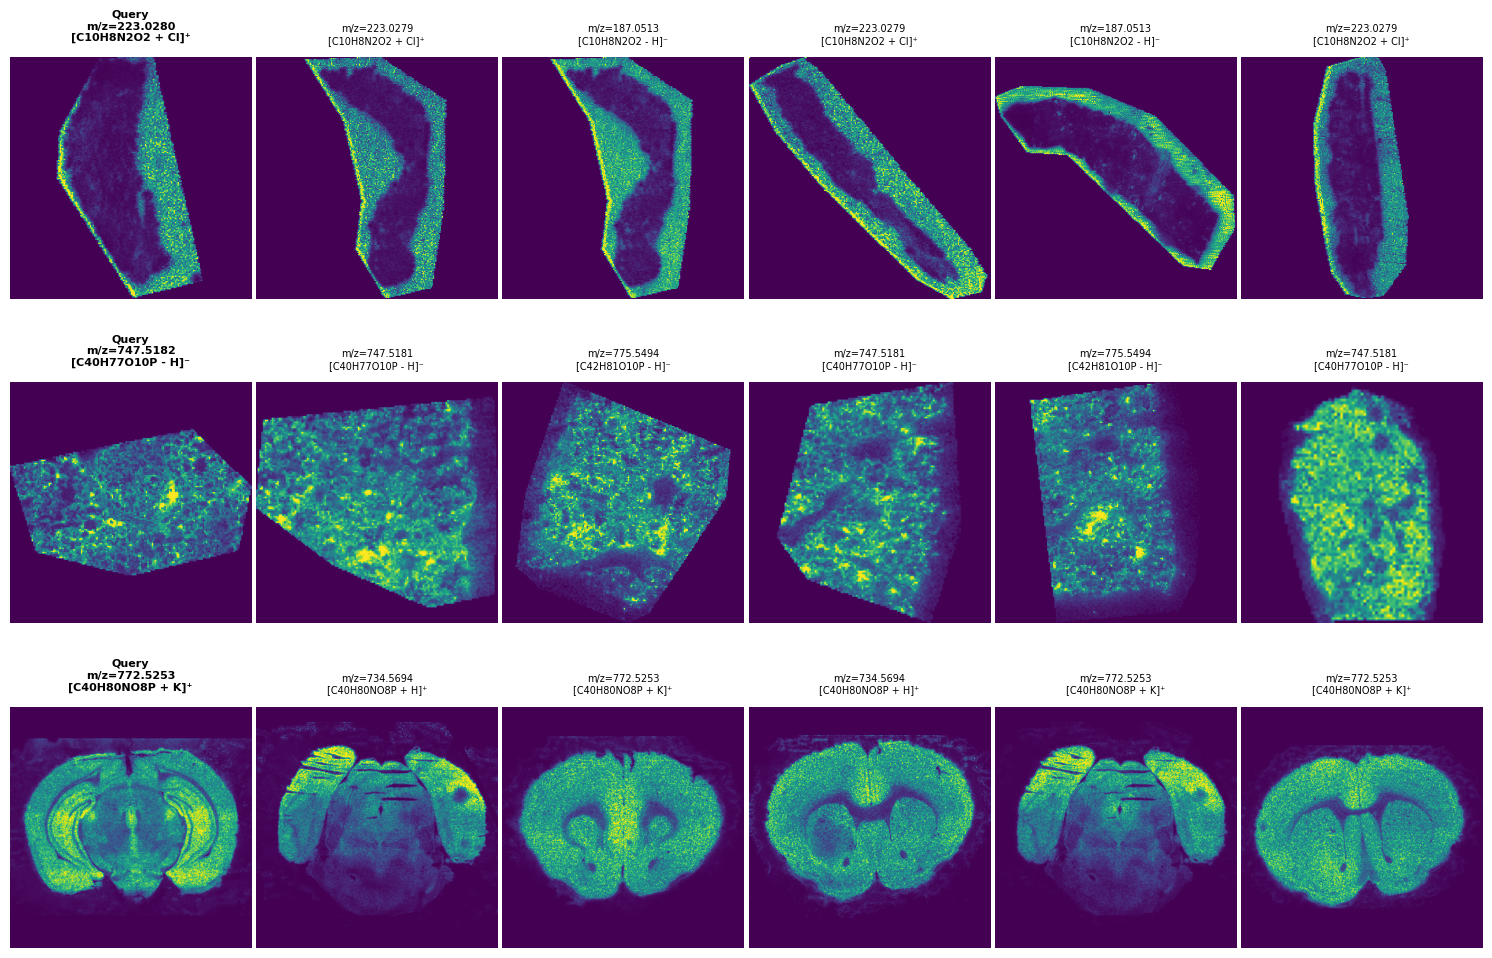

[OK] Saved: Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\benchmarks\neighbors_panels\query_neighbors__channel_emb__fused_all__MAE-MSI.png


In [9]:
"""
CHANNEL-EMBEDDING NEIGHBOR PANELS (Query | top-5 neighbors)

FULLY EDITED:
- You specify queries using:
    QUERY_META_IDXS = [i1, i2, ...]   (indices into msi-vitmae_REBUILT2/embeddings/meta.csv)
  AND:
    QUERY_CHANNEL_IDXS = [c1, c2, ...]  (same length; channel_idx for each query)
  OR:
    QUERY_PAIRS = [(meta_idx, channel_idx), ...].

- For each query: show [Query | top-5 neighbors] on the SAME ROW
- Make every image square by symmetric padding
- Neighbors are restricted to come from DIFFERENT dataset_id than the query
- Saves to OUT_DIR
- Titles now include:
    * Query (for query panels only)
    * m/z=....
    * annotation text built from:
        sum_formula_clean + adduct_clean
      formatted like:
        [C18H36O2 - H]⁻
        [C18H36O2 + Na]⁺

Assumptions (channel-row level):
- spatial_metabolomics_atlas/channel_embeddings/<REP>.npy exists (N, D)
- spatial_metabolomics_atlas/channel_embeddings/row_ids__<REP>.npy exists (N,)  (embedding row -> ch_df row_id)
- metaspace_images_dump/channels_with_candidates.parquet exists and contains:
    dataset_id, tile_r, tile_c, channel_idx, mz, sum_formula_clean, adduct_clean
- msi-vitmae_REBUILT2/embeddings/meta.csv exists and contains:
    dataset_id, tile_r, tile_c, sample_path (to NPZ)
- NPZ has key 'patch' with shape (C,H,W) or (H,W,C) OR has 'mz' that matches last dim.
"""

from __future__ import annotations

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================
SEED = 6741
np.random.seed(SEED)

# --- Channel embeddings (choose one rep) ---
ATLAS_DIR = Path("spatial_metabolomics_atlas") / "channel_embeddings"

REP_NPY    = ATLAS_DIR / "fused_all__MAE-MSI.npy"        # (N, D)
ROWIDS_NPY = ATLAS_DIR / "row_ids__all__MAE-MSI.npy"     # (N,) embedding row -> ch_df row_id

# --- Channel metadata parquet (full channel table) ---
BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"

# --- Tile meta (for sample_path -> NPZ) ---
MSI_EMB_DIR = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV = MSI_EMB_DIR / "meta.csv"

# If meta.csv sample_path is relative, set this root:
NPZ_ROOT: Path | None = None  # e.g. Path(r"Y:\coskun-lab\Efe\MSI Foundation Model")

TOPK = 5
METRIC = "cosine"  # "cosine" or "l2"

# Display mode for MSI stack -> 2D image
SHOW_MODE = "channel"   # "mean" or "channel"
PCTL_LO, PCTL_HI = 1, 99

# Output folder
OUT_DIR = Path(r"Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\benchmarks") / "neighbors_panels"
OUT_PNG = OUT_DIR / f"query_neighbors__channel_emb__{REP_NPY.stem}.png"
DPI = 300

# ------------------------------------------------------------
# YOU SET THESE:
# Option A) Provide pairs directly (recommended)
# ------------------------------------------------------------
QUERY_PAIRS: list[tuple[int, int]] = [
    # (meta_idx, channel_idx)
    (0, 0),
    (78, 0),
    (798, 0),
]

# Option B) Provide two parallel lists (same length) instead
# QUERY_META_IDXS: list[int] = [78, 4359]
# QUERY_CHANNEL_IDXS: list[int] = [0, 12]


# ============================================================
# HELPERS
# ============================================================

_SUP_PLUS = "⁺"
_SUP_MINUS = "⁻"


def safe_str(x) -> str:
    if x is None:
        return "unknown"
    try:
        if pd.isna(x):
            return "unknown"
    except Exception:
        pass
    s = str(x).strip()
    return s if s else "unknown"


def _clean_str(x) -> str | None:
    if x is None:
        return None
    try:
        if pd.isna(x):
            return None
    except Exception:
        pass
    s = str(x).strip()
    return s if s else None


def sanitize_label_text(x) -> str:
    s = _clean_str(x)
    if s is None:
        return ""
    return " ".join(str(s).split())


def truncate_label(s: str, max_len: int = 80) -> str:
    s = str(s)
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")


def resolve_path(p: str | Path) -> Path:
    p = Path(str(p))
    if p.is_absolute():
        return p
    if NPZ_ROOT is not None:
        return NPZ_ROOT / p
    return p


def l2_normalize_rows(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    n = np.linalg.norm(X, axis=1, keepdims=True) + eps
    return X / n


def square_pad(img2d: np.ndarray, pad_value: float = 0.0) -> np.ndarray:
    img = np.asarray(img2d)
    if img.ndim != 2:
        raise ValueError(f"square_pad expects 2D image, got {img.shape}")
    h, w = img.shape
    if h == w:
        return img
    if h < w:
        d = w - h
        top = d // 2
        bottom = d - top
        return np.pad(img, ((top, bottom), (0, 0)), mode="constant", constant_values=pad_value)
    d = h - w
    left = d // 2
    right = d - left
    return np.pad(img, ((0, 0), (left, right)), mode="constant", constant_values=pad_value)


def load_npz_patch(npz_path: Path) -> np.ndarray:
    """
    Returns patch as (C,H,W).
    Handles:
      - patch already (C,H,W)
      - patch (H,W,C) (heuristic)
      - patch (H,W,C) + mz (C,)  (strong hint)
    """
    npz_path = Path(npz_path)
    if not npz_path.exists():
        raise FileNotFoundError(f"NPZ not found: {npz_path}")

    with np.load(npz_path, allow_pickle=False) as z:
        if "patch" not in z:
            raise KeyError(f"NPZ missing 'patch': {npz_path} keys={list(z.keys())}")
        patch = np.asarray(z["patch"])
        mz = z["mz"] if "mz" in z else None

    if patch.ndim != 3:
        raise ValueError(f"Expected patch.ndim==3, got {patch.shape}")

    if mz is not None:
        mz = np.asarray(mz)
        if mz.ndim == 1 and patch.shape[-1] == mz.shape[0]:
            return np.moveaxis(patch, -1, 0)

    if patch.shape[-1] <= 512 and patch.shape[0] > patch.shape[-1] and patch.shape[1] > patch.shape[-1]:
        patch = np.moveaxis(patch, -1, 0)

    return patch


def _norm_img(img: np.ndarray) -> np.ndarray:
    img = np.asarray(img, dtype=np.float32)
    lo, hi = np.percentile(img, [PCTL_LO, PCTL_HI])
    img = (img - lo) / (hi - lo + 1e-8)
    img = np.clip(img, 0.0, 1.0)
    return img


def patch_to_vis(patch_chw: np.ndarray, *, mode: str, channel: int) -> np.ndarray:
    c, h, w = patch_chw.shape
    if mode == "mean":
        img = patch_chw.mean(axis=0)
    elif mode == "channel":
        ch = int(channel)
        if not (0 <= ch < c):
            ch = 0
        img = patch_chw[ch]
    else:
        raise ValueError("mode must be 'mean' or 'channel'")
    return square_pad(_norm_img(img), pad_value=0.0)


def build_msi_row_index(meta_df: pd.DataFrame) -> dict[tuple[str, int, int], int]:
    needed = {"dataset_id", "tile_r", "tile_c"}
    miss = needed - set(meta_df.columns)
    if miss:
        raise KeyError(f"MSI meta.csv missing columns: {sorted(miss)}")

    key_to_i: dict[tuple[str, int, int], int] = {}
    for i, r in meta_df.reset_index(drop=True).iterrows():
        key = (str(r["dataset_id"]), int(r["tile_r"]), int(r["tile_c"]))
        if key not in key_to_i:
            key_to_i[key] = int(i)
    return key_to_i


def _infer_channel_col(ch_df: pd.DataFrame) -> str:
    candidates = ["channel_idx", "chan", "channel", "channel_i", "ch", "c"]
    cols = set(map(str, ch_df.columns))
    for c in candidates:
        if c in cols:
            return c

    lower_map = {str(c).strip().lower(): str(c) for c in ch_df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]

    raise KeyError(
        "Could not find channel index column in channels_with_candidates.parquet. "
        "Expected one of: channel_idx/chan/channel/channel_i/ch/c"
    )


def _infer_mz_col(ch_df: pd.DataFrame) -> str | None:
    lower_map = {str(c).strip().lower(): str(c) for c in ch_df.columns}
    for key in ["mz", "m/z", "mz_value", "mz_center"]:
        if key in lower_map:
            return lower_map[key]
    return None


def _find_formula_col(ch_df: pd.DataFrame) -> str | None:
    lower_map = {str(c).strip().lower(): str(c) for c in ch_df.columns}
    for key in ["sum_formula_clean", "formula", "sum_formula", "molecular_formula"]:
        if key in lower_map:
            return lower_map[key]
    return None


def _find_adduct_col(ch_df: pd.DataFrame) -> str | None:
    lower_map = {str(c).strip().lower(): str(c) for c in ch_df.columns}
    for key in ["adduct_clean", "adduct", "ion_adduct"]:
        if key in lower_map:
            return lower_map[key]
    return None


def format_formula_adduct(formula: str | None, adduct: str | None) -> str | None:
    """
    Examples:
      formula=C18H36O2, adduct=-H   -> [C18H36O2 - H]⁻
      formula=C18H36O2, adduct=+Na  -> [C18H36O2 + Na]⁺
      formula=C18H36O2, adduct=None -> [C18H36O2]
    """
    f = _clean_str(formula)
    a = _clean_str(adduct)

    if f is None and a is None:
        return None
    if f is None:
        return a
    if a is None:
        return f"[{f}]"

    a0 = a.replace(" ", "")
    if a0.startswith("+"):
        ion = a0[1:]
        return f"[{f} + {ion}]{_SUP_PLUS}" if ion else f"[{f}]{_SUP_PLUS}"
    if a0.startswith("-"):
        ion = a0[1:]
        return f"[{f} - {ion}]{_SUP_MINUS}" if ion else f"[{f}]{_SUP_MINUS}"

    return f"[{f} {a}]"


def build_annotation_text(
    row: pd.Series,
    *,
    formula_col: str | None,
    adduct_col: str | None,
) -> str | None:
    formula = row.get(formula_col, None) if formula_col is not None else None
    adduct = row.get(adduct_col, None) if adduct_col is not None else None
    txt = format_formula_adduct(formula, adduct)
    if txt is None:
        return None
    return truncate_label(sanitize_label_text(txt), max_len=80)


def label_for_channel_row(
    row: pd.Series,
    *,
    mz_col: str | None,
    formula_col: str | None,
    adduct_col: str | None,
    is_query: bool,
) -> str:
    lines = []

    if is_query:
        lines.append("Query")

    mz_txt = "m/z=?"
    if mz_col is not None and mz_col in row.index:
        try:
            mz_val = row[mz_col]
            if mz_val is not None and not (isinstance(mz_val, float) and np.isnan(mz_val)):
                mz_txt = f"m/z={float(mz_val):.4f}"
        except Exception:
            pass
    lines.append(mz_txt)

    ann = build_annotation_text(
        row,
        formula_col=formula_col,
        adduct_col=adduct_col,
    )
    if ann:
        lines.append(ann)

    return "\n".join(lines)


def _get_meta_key(meta_row: pd.Series) -> tuple[str, int, int]:
    return (str(meta_row["dataset_id"]), int(meta_row["tile_r"]), int(meta_row["tile_c"]))


def resolve_query_to_chdf_rowid(
    *,
    meta_idx: int,
    channel_idx: int,
    msi_meta_df: pd.DataFrame,
    ch_df: pd.DataFrame,
    chan_col: str,
    meta_key_to_ch_rowids: dict[tuple[str, int, int], np.ndarray],
) -> int:
    if not (0 <= int(meta_idx) < len(msi_meta_df)):
        raise IndexError(f"meta_idx out of range: {meta_idx} (valid 0..{len(msi_meta_df)-1})")

    mr = msi_meta_df.iloc[int(meta_idx)]
    key = _get_meta_key(mr)
    cand = meta_key_to_ch_rowids.get(key, None)
    if cand is None or len(cand) == 0:
        raise KeyError(f"No channels found in ch_df for meta row key={key} (meta_idx={meta_idx})")

    want = int(channel_idx)
    sub = ch_df.iloc[cand]
    mask = sub[chan_col].astype(int).values == want

    if mask.sum() == 0:
        avail = np.unique(sub[chan_col].astype(int).values)
        preview = ", ".join(map(str, avail[:20]))
        raise KeyError(
            f"No ch_df row matches meta_idx={meta_idx} key={key} with channel_idx={want}. "
            f"Available channel_idx for this tile (first 20): {preview}"
        )

    chosen = int(cand[np.flatnonzero(mask)[0]])
    return chosen


def read_msi_image_for_ch_row(
    ch_row: pd.Series,
    *,
    msi_meta_df: pd.DataFrame,
    msi_key_to_i: dict[tuple[str, int, int], int],
    chan_idx_for_display: int,
) -> np.ndarray | None:
    try:
        ds = str(ch_row["dataset_id"])
        tr = int(ch_row["tile_r"])
        tc = int(ch_row["tile_c"])
    except Exception:
        return None

    j = msi_key_to_i.get((ds, tr, tc), None)
    if j is None:
        return None
    if "sample_path" not in msi_meta_df.columns:
        return None

    sp = msi_meta_df.at[j, "sample_path"]
    if sp is None or (isinstance(sp, float) and np.isnan(sp)):
        return None

    try:
        patch = load_npz_patch(resolve_path(sp))
        if SHOW_MODE == "channel":
            return patch_to_vis(patch, mode="channel", channel=int(chan_idx_for_display))
        return patch_to_vis(patch, mode="mean", channel=0)
    except Exception:
        return None


def find_neighbors_excluding_same_dataset(
    Z: np.ndarray,
    q: int,
    *,
    topk: int,
    metric: str,
    ds_of_embed: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    n = Z.shape[0]
    q = int(q)
    metric = metric.lower().strip()
    if metric not in {"cosine", "l2"}:
        raise ValueError("metric must be 'cosine' or 'l2'")

    if not (0 <= q < n):
        raise IndexError(f"q out of range: {q} (N={n})")

    q_ds = ds_of_embed[q]
    forbid = (ds_of_embed == q_ds)
    forbid[q] = True

    eligible = (~forbid).sum()
    if eligible <= 0:
        return np.array([], dtype=np.int64), np.array([], dtype=np.float32)

    topk_eff = min(int(topk), int(eligible))

    if metric == "cosine":
        z_l2 = l2_normalize_rows(Z)
        qv = z_l2[q]
        sims = z_l2 @ qv
        sims[forbid] = -np.inf
        nn = np.argpartition(-sims, kth=topk_eff - 1)[:topk_eff]
        nn = nn[np.argsort(-sims[nn])]
        return nn.astype(np.int64), sims[nn].astype(np.float32)

    qv = np.asarray(Z[q], dtype=np.float32)
    dif = np.asarray(Z, dtype=np.float32) - qv
    d2 = np.einsum("ij,ij->i", dif, dif).astype(np.float32)
    d2[forbid] = np.inf
    nn = np.argpartition(d2, kth=topk_eff - 1)[:topk_eff]
    nn = nn[np.argsort(d2[nn])]
    scores = (-np.sqrt(d2[nn] + 1e-12)).astype(np.float32)
    return nn.astype(np.int64), scores


# ============================================================
# LOAD
# ============================================================
if not REP_NPY.exists():
    raise FileNotFoundError(f"Missing channel embeddings: {REP_NPY}")
if not ROWIDS_NPY.exists():
    raise FileNotFoundError(f"Missing row_ids for channel embeddings: {ROWIDS_NPY}")
if not CHAN_PQ.exists():
    raise FileNotFoundError(f"Missing channel parquet: {CHAN_PQ}")
if not MSI_META_CSV.exists():
    raise FileNotFoundError(f"Missing: {MSI_META_CSV}")

Z = np.load(REP_NPY, mmap_mode="r")
emb_rowids = np.load(ROWIDS_NPY).astype(np.int64)

if Z.ndim != 2:
    raise ValueError(f"Z must be 2D, got {Z.shape}")
if emb_rowids.ndim != 1 or emb_rowids.shape[0] != Z.shape[0]:
    raise ValueError(f"row_ids must be (N,), got {emb_rowids.shape} vs Z {Z.shape}")

ch_df = pd.read_parquet(CHAN_PQ)
msi_meta = pd.read_csv(MSI_META_CSV)

need_ch_cols = {"dataset_id", "tile_r", "tile_c"}
miss_ch = need_ch_cols - set(ch_df.columns)
if miss_ch:
    raise KeyError(f"channels_with_candidates.parquet missing required columns: {sorted(miss_ch)}")

chan_col = _infer_channel_col(ch_df)
mz_col = _infer_mz_col(ch_df)
formula_col = _find_formula_col(ch_df)
adduct_col = _find_adduct_col(ch_df)

if formula_col is None:
    raise KeyError("Could not find formula column. Expected something like 'sum_formula_clean'.")
if adduct_col is None:
    raise KeyError("Could not find adduct column. Expected something like 'adduct_clean'.")

msi_key_to_i = build_msi_row_index(msi_meta)

# ============================================================
# Build mapping: ch_df row_id <-> embedding index
# ============================================================
rid_to_embed: dict[int, int] = {}
for ei, rid in enumerate(emb_rowids.tolist()):
    rid = int(rid)
    if rid not in rid_to_embed:
        rid_to_embed[rid] = int(ei)

# ============================================================
# Build fast index: (dataset_id,tile_r,tile_c) -> row ids
# ============================================================
ds_vals = ch_df["dataset_id"].astype(str).values
tr_vals = ch_df["tile_r"].astype(int).values
tc_vals = ch_df["tile_c"].astype(int).values
keys = list(zip(ds_vals.tolist(), tr_vals.tolist(), tc_vals.tolist()))

meta_key_to_ch_rowids: dict[tuple[str, int, int], list[int]] = {}
for rid, k in enumerate(keys):
    if k not in meta_key_to_ch_rowids:
        meta_key_to_ch_rowids[k] = []
    meta_key_to_ch_rowids[k].append(int(rid))

meta_key_to_ch_rowids_np: dict[tuple[str, int, int], np.ndarray] = {
    k: np.asarray(v, dtype=np.int64) for k, v in meta_key_to_ch_rowids.items()
}

# ============================================================
# Parse queries
# ============================================================
if "QUERY_META_IDXS" in globals() and "QUERY_CHANNEL_IDXS" in globals():
    if len(QUERY_META_IDXS) != len(QUERY_CHANNEL_IDXS):
        raise ValueError("QUERY_META_IDXS and QUERY_CHANNEL_IDXS must have same length.")
    QUERY_PAIRS = list(zip([int(x) for x in QUERY_META_IDXS], [int(x) for x in QUERY_CHANNEL_IDXS]))

if not QUERY_PAIRS:
    raise ValueError("You must set QUERY_PAIRS (or QUERY_META_IDXS + QUERY_CHANNEL_IDXS).")

QUERY_PAIRS = [(int(mi), int(ci)) for mi, ci in QUERY_PAIRS]

# ============================================================
# Resolve queries
# ============================================================
QUERY_CH_ROWIDS: list[int] = []
QUERY_EMBED_IDXS: list[int] = []

for (meta_idx, channel_idx) in QUERY_PAIRS:
    ch_rid = resolve_query_to_chdf_rowid(
        meta_idx=meta_idx,
        channel_idx=channel_idx,
        msi_meta_df=msi_meta,
        ch_df=ch_df,
        chan_col=chan_col,
        meta_key_to_ch_rowids=meta_key_to_ch_rowids_np,
    )
    if ch_rid not in rid_to_embed:
        raise KeyError(
            f"Query (meta_idx={meta_idx}, channel_idx={channel_idx}) resolved to ch_df row_id={ch_rid}, "
            f"but that row_id is NOT present in this representation's ROWIDS_NPY."
        )
    QUERY_CH_ROWIDS.append(int(ch_rid))
    QUERY_EMBED_IDXS.append(int(rid_to_embed[int(ch_rid)]))

print("[INFO] REP:", REP_NPY)
print("[INFO] SHOW_MODE:", SHOW_MODE, "| METRIC:", METRIC, "| TOPK:", TOPK)
print("[INFO] Formula column:", formula_col)
print("[INFO] Adduct column:", adduct_col)
print("[INFO] Query pairs (meta_idx, channel_idx):", QUERY_PAIRS)
print("[INFO] Resolved ch_df row_ids:", QUERY_CH_ROWIDS)
print("[INFO] Resolved embedding idxs:", QUERY_EMBED_IDXS)

# ============================================================
# Precompute dataset_id per embedding row
# ============================================================
ds_of_embed = ch_df.loc[emb_rowids, "dataset_id"].astype(str).values

# ============================================================
# Compute neighbors
# ============================================================
rows = []
for q_ei in QUERY_EMBED_IDXS:
    nn_ei, sc = find_neighbors_excluding_same_dataset(
        Z, q_ei, topk=TOPK, metric=METRIC, ds_of_embed=ds_of_embed
    )
    rows.append((q_ei, nn_ei, sc))

# ============================================================
# Plot
# ============================================================
os.makedirs(OUT_DIR, exist_ok=True)

n_rows = len(rows)
n_cols = 1 + TOPK
fig_w = 2.5 * n_cols
fig_h = 3.35 * n_rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), squeeze=False)

for r_i, (q_ei, nn_ei, sc) in enumerate(rows):
    # ---------------- Query ----------------
    ax = axes[r_i, 0]
    q_rid = int(emb_rowids[q_ei])
    q_row = ch_df.iloc[q_rid]

    q_pos = QUERY_EMBED_IDXS.index(q_ei)
    q_meta_idx, q_chan_idx = QUERY_PAIRS[q_pos]

    img = read_msi_image_for_ch_row(
        q_row,
        msi_meta_df=msi_meta,
        msi_key_to_i=msi_key_to_i,
        chan_idx_for_display=q_chan_idx,
    )

    if img is None:
        ax.text(0.5, 0.5, "image\nunavailable", ha="center", va="center", fontsize=10)
        ax.set_facecolor("white")
    else:
        ax.imshow(img, cmap="viridis", vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title(
        label_for_channel_row(
            q_row,
            mz_col=mz_col,
            formula_col=formula_col,
            adduct_col=adduct_col,
            is_query=True,
        ),
        fontsize=8,
        fontweight="bold",
        pad=12,
    )

    # ---------------- Neighbors ----------------
    for j in range(TOPK):
        ax = axes[r_i, 1 + j]
        if j >= nn_ei.size:
            ax.text(0.5, 0.5, "no\neligible\nneighbor", ha="center", va="center", fontsize=9)
            ax.set_facecolor("white")
            ax.axis("off")
            continue

        nei = int(nn_ei[j])
        n_rid = int(emb_rowids[nei])
        n_row = ch_df.iloc[n_rid]

        try:
            n_chan_idx = int(n_row[chan_col])
        except Exception:
            n_chan_idx = 0

        img = read_msi_image_for_ch_row(
            n_row,
            msi_meta_df=msi_meta,
            msi_key_to_i=msi_key_to_i,
            chan_idx_for_display=n_chan_idx,
        )

        if img is None:
            ax.text(0.5, 0.5, "image\nunavailable", ha="center", va="center", fontsize=10)
            ax.set_facecolor("white")
        else:
            ax.imshow(img, cmap="viridis", vmin=0, vmax=1)
        ax.axis("off")
        ax.set_title(
            label_for_channel_row(
                n_row,
                mz_col=mz_col,
                formula_col=formula_col,
                adduct_col=adduct_col,
                is_query=False,
            ),
            fontsize=7,
            pad=10,
        )

plt.tight_layout(pad=1.0, w_pad=0.35, h_pad=2.0)
plt.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
plt.show()

print("[OK] Saved:", OUT_PNG)